In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt #helping at data visualization
import seaborn as sns #creating visual informations about data set

import os

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session
import plotly.express as px
import plotly.graph_objs as go
import warnings
warnings.filterwarnings("ignore")

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
world_happiness = pd.read_csv("data/World-happiness-report-updated_2024.csv", encoding = "latin1")
df = world_happiness.copy()
df.head()

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
0,Afghanistan,2008,3.724,7.350,0.451,50.5,0.718,0.164,0.882,0.414,0.258
1,Afghanistan,2009,4.402,7.509,0.552,50.8,0.679,0.187,0.850,0.481,0.237
2,Afghanistan,2010,4.758,7.614,0.539,51.1,0.600,0.118,0.707,0.517,0.275
3,Afghanistan,2011,3.832,7.581,0.521,51.4,0.496,0.160,0.731,0.480,0.267
4,Afghanistan,2012,3.783,7.661,0.521,51.7,0.531,0.234,0.776,0.614,0.268


In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
df.describe()

,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
count,2363.000000,2363.000000,2335.000000,2350.000000,2300.000000,2327.000000,2282.000000,2238.000000,2339.000000,2347.000000
mean,2014.763860,5.483566,9.399671,0.809369,63.401828,0.750282,0.000098,0.743971,0.651882,0.273151
std,5.059436,1.125522,1.152069,0.121212,6.842644,0.139357,0.161388,0.184865,0.106240,0.087131
min,2005.000000,1.281000,5.527000,0.228000,6.720000,0.228000,-0.340000,0.035000,0.179000,0.083000
25%,2011.000000,4.647000,8.506500,0.744000,59.195000,0.661000,-0.112000,0.687000,0.572000,0.209000
50%,2015.000000,5.449000,9.503000,0.834500,65.100000,0.771000,-0.022000,0.798500,0.663000,0.262000
75%,2019.000000,6.323500,10.392500,0.904000,68.552500,0.862000,0.093750,0.867750,0.737000,0.326000
max,2023.000000,8.019000,11.676000,0.987000,74.600000,0.985000,0.700000,0.983000,0.884000,0.705000


In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2363 entries, 0 to 2362
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country name                      2363 non-null   object 
 1   year                              2363 non-null   int64  
 2   Life Ladder                       2363 non-null   float64
 3   Log GDP per capita                2335 non-null   float64
 4   Social support                    2350 non-null   float64
 5   Healthy life expectancy at birth  2300 non-null   float64
 6   Freedom to make life choices      2327 non-null   float64
 7   Generosity                        2282 non-null   float64
 8   Perceptions of corruption         2238 non-null   float64
 9   Positive affect                   2339 non-null   float64
 10  Negative affect                   2347 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 203.2+ KB


In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
#ищем пропушенные значения 
df.isnull().sum()

Country name                          0
year                                  0
Life Ladder                           0
Log GDP per capita                   28
Social support                       13
Healthy life expectancy at birth     63
Freedom to make life choices         36
Generosity                           81
Perceptions of corruption           125
Positive affect                      24
Negative affect                      16
dtype: int64

In [6]:
# --- [CELL 5]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
#удаление пропущенных значений
df = df.dropna()
df.isnull().sum()

Country name                        0
year                                0
Life Ladder                         0
Log GDP per capita                  0
Social support                      0
Healthy life expectancy at birth    0
Freedom to make life choices        0
Generosity                          0
Perceptions of corruption           0
Positive affect                     0
Negative affect                     0
dtype: int64

In [7]:
# --- [CELL 6]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 7}
world_happiness2024 = pd.read_csv("data/World-happiness-report-2024.csv")
df2024 = world_happiness2024.copy()
df2024.head()

,Country name,Regional indicator,Ladder score,upperwhisker,lowerwhisker,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.741,7.815,7.667,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,Western Europe,7.583,7.665,7.500,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,Western Europe,7.525,7.618,7.433,1.881,1.617,0.718,0.819,0.258,0.182,2.050
3,Sweden,Western Europe,7.344,7.422,7.267,1.878,1.501,0.724,0.838,0.221,0.524,1.658
4,Israel,Middle East and North Africa,7.341,7.405,7.277,1.803,1.513,0.740,0.641,0.153,0.193,2.298


In [8]:
# --- [CELL 7]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 8}
df2024.describe()

,Ladder score,upperwhisker,lowerwhisker,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
count,143.000000,143.000000,143.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000
mean,5.527580,5.641175,5.413972,1.378807,1.134329,0.520886,0.620621,0.146271,0.154121,1.575914
std,1.170717,1.155008,1.187133,0.425098,0.333317,0.164923,0.162492,0.073441,0.126238,0.537459
min,1.721000,1.775000,1.667000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.073000
25%,4.726000,4.845500,4.606000,1.077750,0.921750,0.398000,0.527500,0.091000,0.068750,1.308250
50%,5.785000,5.895000,5.674000,1.431500,1.237500,0.549500,0.641000,0.136500,0.120500,1.644500
75%,6.416000,6.507500,6.319000,1.741500,1.383250,0.648500,0.736000,0.192500,0.193750,1.881750
max,7.741000,7.815000,7.667000,2.141000,1.617000,0.857000,0.863000,0.401000,0.575000,2.998000


In [9]:
# --- [CELL 8]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 9}
#general information of data
df2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country name                  143 non-null    object 
 1   Regional indicator            143 non-null    object 
 2   Ladder score                  143 non-null    float64
 3   upperwhisker                  143 non-null    float64
 4   lowerwhisker                  143 non-null    float64
 5   Log GDP per capita            140 non-null    float64
 6   Social support                140 non-null    float64
 7   Healthy life expectancy       140 non-null    float64
 8   Freedom to make life choices  140 non-null    float64
 9   Generosity                    140 non-null    float64
 10  Perceptions of corruption     140 non-null    float64
 11  Dystopia + residual           140 non-null    float64
dtypes: float64(10), object(2)
memory usage: 13.5+ KB


In [10]:
# --- [CELL 9]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 10}
df2024['Country name'].unique()

array(['Finland', 'Denmark', 'Iceland', 'Sweden', 'Israel', 'Netherlands',
       'Norway', 'Luxembourg', 'Switzerland', 'Australia', 'New Zealand',
       'Costa Rica', 'Kuwait', 'Austria', 'Canada', 'Belgium', 'Ireland',
       'Czechia', 'Lithuania', 'United Kingdom', 'Slovenia',
       'United Arab Emirates', 'United States', 'Germany', 'Mexico',
       'Uruguay', 'France', 'Saudi Arabia', 'Kosovo', 'Singapore',
       'Taiwan Province of China', 'Romania', 'El Salvador', 'Estonia',
       'Poland', 'Spain', 'Serbia', 'Chile', 'Panama', 'Malta', 'Italy',
       'Guatemala', 'Nicaragua', 'Brazil', 'Slovakia', 'Latvia',
       'Uzbekistan', 'Argentina', 'Kazakhstan', 'Cyprus', 'Japan',
       'South Korea', 'Philippines', 'Vietnam', 'Portugal', 'Hungary',
       'Paraguay', 'Thailand', 'Malaysia', 'China', 'Honduras', 'Bahrain',
       'Croatia', 'Greece', 'Bosnia and Herzegovina', 'Libya', 'Jamaica',
       'Peru', 'Dominican Republic', 'Mauritius', 'Moldova', 'Russia',
       'Boli

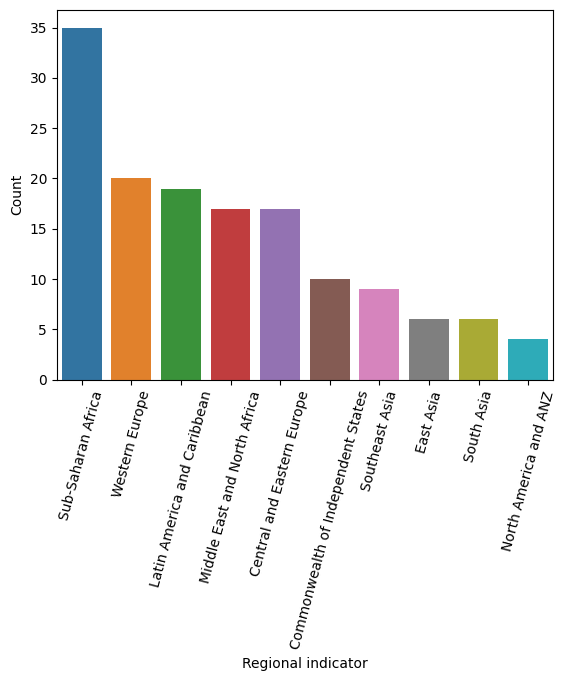

In [11]:
# --- [CELL 10]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 11}
regional_counts = df2024["Regional indicator"].value_counts().reset_index()
regional_counts.columns = ["Regional indicator", "Count"]

sns.barplot(data = regional_counts, x = "Regional indicator", y = "Count")
plt.xticks(rotation = 75)
plt.show()

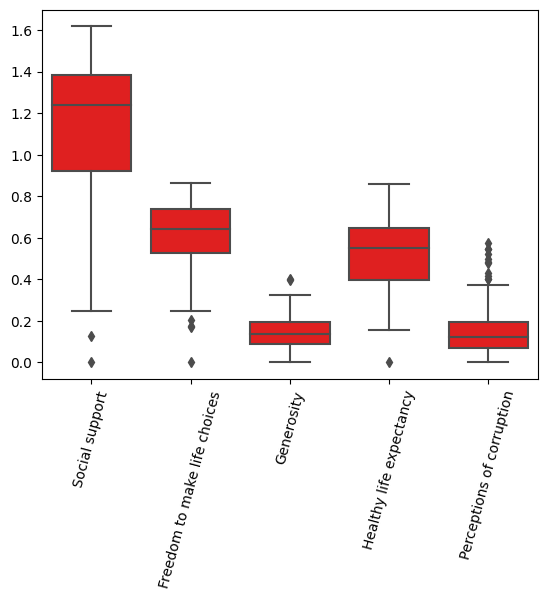

In [12]:
# --- [CELL 11]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 12}
list_features = ["Social support", "Freedom to make life choices", "Generosity", 
                 "Healthy life expectancy","Perceptions of corruption"]
sns.boxplot(data = df2024.loc[:, list_features], orient = "v", color = "red")
plt.xticks(rotation = 75)
plt.show()

<Axes: >

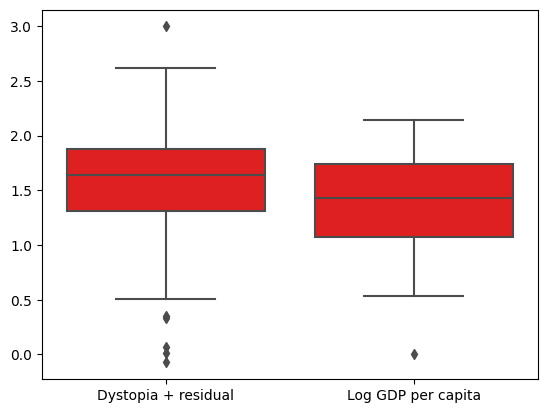

In [13]:
# --- [CELL 12]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 13}
list_features = ["Dystopia + residual", "Log GDP per capita"]
sns.boxplot(data = df2024.loc[:, list_features], orient = "v", color = "red")

<Axes: >

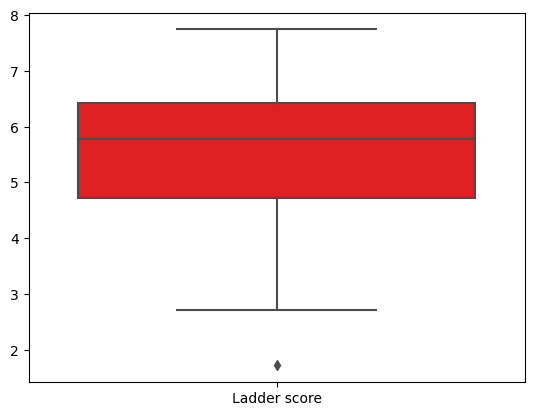

In [14]:
# --- [CELL 13]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 14}
list_feature = ["Ladder score"]
sns.boxplot(data = df2024.loc[:, list_feature], orient = "v", color = "red")

СТАТИСТИКА ДЛЯ ПЕРВОГО НАБОРА ПРИЗНАКОВ

Признак: Social support
  Медиана: 1.2375
  Первый квартиль (Q1): 0.9218
  Третий квартиль (Q3): 1.3832
  Межквартильный размах (IQR): 0.4615
  Нижний ус: 0.2295
  Верхний ус: 2.0755
  Количество выбросов: 2
  Выбросы: [0.128, 0.0]

Признак: Freedom to make life choices
  Медиана: 0.6410
  Первый квартиль (Q1): 0.5275
  Третий квартиль (Q3): 0.7360
  Межквартильный размах (IQR): 0.2085
  Нижний ус: 0.2148
  Верхний ус: 1.0487
  Количество выбросов: 4
  Выбросы: [0.202, 0.172, 0.173, 0.0]

Признак: Generosity
  Медиана: 0.1365
  Первый квартиль (Q1): 0.0910
  Третий квартиль (Q3): 0.1925
  Межквартильный размах (IQR): 0.1015
  Нижний ус: -0.0612
  Верхний ус: 0.3448
  Количество выбросов: 2
  Выбросы: [0.399, 0.401]

Признак: Healthy life expectancy
  Медиана: 0.5495
  Первый квартиль (Q1): 0.3980
  Третий квартиль (Q3): 0.6485
  Межквартильный размах (IQR): 0.2505
  Нижний ус: 0.0222
  Верхний ус: 1.0243
  Количество выбросов: 1
  Выбросы: [0.0]

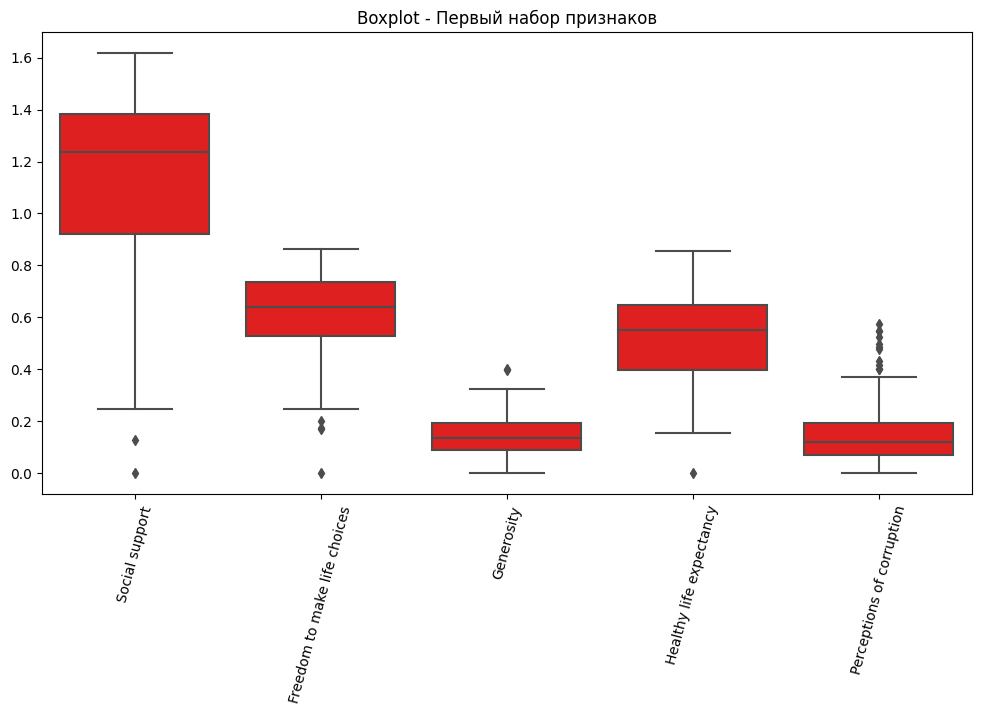


СТАТИСТИКА ДЛЯ ВТОРОГО НАБОРА ПРИЗНАКОВ

Признак: Dystopia + residual
  Медиана: 1.6445
  Первый квартиль (Q1): 1.3083
  Третий квартиль (Q3): 1.8818
  Межквартильный размах (IQR): 0.5735
  Нижний ус: 0.4480
  Верхний ус: 2.7420
  Количество выбросов: 6
  Выбросы: [2.998, 0.333, 0.349, 0.014, 0.066, -0.073]

Признак: Log GDP per capita
  Медиана: 1.4315
  Первый квартиль (Q1): 1.0777
  Третий квартиль (Q3): 1.7415
  Межквартильный размах (IQR): 0.6638
  Нижний ус: 0.0821
  Верхний ус: 2.7371
  Количество выбросов: 1
  Выбросы: [0.0]


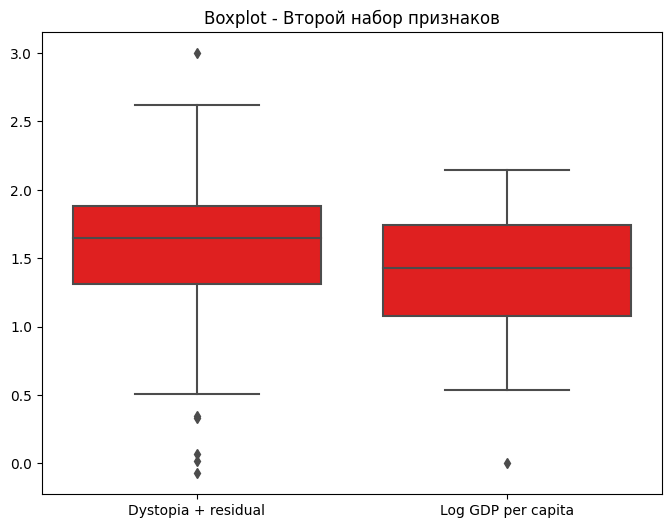


СТАТИСТИКА ДЛЯ LADDER SCORE

Признак: Ladder score
  Медиана: 5.7850
  Первый квартиль (Q1): 4.7260
  Третий квартиль (Q3): 6.4160
  Межквартильный размах (IQR): 1.6900
  Нижний ус: 2.1910
  Верхний ус: 8.9510
  Количество выбросов: 1
  Выбросы: [1.721]


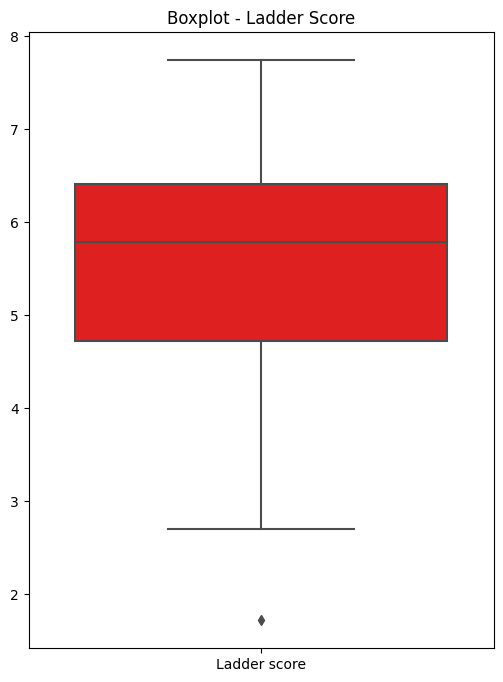


СВОДНАЯ ТАБЛИЦА СТАТИСТИК
                     Признак Медиана     Q1     Q3    IQR  Выбросы
              Social support  1.2375 0.9218 1.3832 0.4615        2
Freedom to make life choices  0.6410 0.5275 0.7360 0.2085        4
                  Generosity  0.1365 0.0910 0.1925 0.1015        2
     Healthy life expectancy  0.5495 0.3980 0.6485 0.2505        1
   Perceptions of corruption  0.1205 0.0688 0.1938 0.1250       11
         Dystopia + residual  1.6445 1.3083 1.8818 0.5735        6
          Log GDP per capita  1.4315 1.0777 1.7415 0.6638        1
                Ladder score  5.7850 4.7260 6.4160 1.6900        1


In [15]:
# --- [CELL 14]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 15}
import numpy as np

# Функция для вычисления статистики
def calculate_boxplot_stats(data, feature_name):
    # Убираем NaN значения
    clean_data = data.dropna()
    
    # Квартили
    q1 = np.percentile(clean_data, 25)
    q3 = np.percentile(clean_data, 75)
    median_val = np.percentile(clean_data, 50)
    
    # Межквартильный размах
    iqr = q3 - q1
    
    # Границы усов
    lower_whisker = q1 - 1.5 * iqr
    upper_whisker = q3 + 1.5 * iqr
    
    # Выбросы
    outliers = clean_data[(clean_data < lower_whisker) | (clean_data > upper_whisker)]
    
    return {
        'feature': feature_name,
        'median': median_val,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_whisker': lower_whisker,
        'upper_whisker': upper_whisker,
        'outliers': outliers.tolist(),
        'outliers_count': len(outliers),
        'min': clean_data.min(),
        'max': clean_data.max()
    }

# Первый набор признаков
list_features1 = ["Social support", "Freedom to make life choices", "Generosity", 
                 "Healthy life expectancy", "Perceptions of corruption"]

print("=" * 80)
print("СТАТИСТИКА ДЛЯ ПЕРВОГО НАБОРА ПРИЗНАКОВ")
print("=" * 80)

for feature in list_features1:
    stats = calculate_boxplot_stats(df2024[feature], feature)
    print(f"\nПризнак: {stats['feature']}")
    print(f"  Медиана: {stats['median']:.4f}")
    print(f"  Первый квартиль (Q1): {stats['q1']:.4f}")
    print(f"  Третий квартиль (Q3): {stats['q3']:.4f}")
    print(f"  Межквартильный размах (IQR): {stats['iqr']:.4f}")
    print(f"  Нижний ус: {stats['lower_whisker']:.4f}")
    print(f"  Верхний ус: {stats['upper_whisker']:.4f}")
    print(f"  Количество выбросов: {stats['outliers_count']}")
    if stats['outliers_count'] > 0:
        print(f"  Выбросы: {stats['outliers']}")

# Boxplot для первого набора
plt.figure(figsize=(12, 6))
sns.boxplot(data=df2024.loc[:, list_features1], orient="v", color="red")
plt.xticks(rotation=75)
plt.title("Boxplot - Первый набор признаков")
plt.show()

# Второй набор признаков
list_features2 = ["Dystopia + residual", "Log GDP per capita"]

print("\n" + "=" * 80)
print("СТАТИСТИКА ДЛЯ ВТОРОГО НАБОРА ПРИЗНАКОВ")
print("=" * 80)

for feature in list_features2:
    stats = calculate_boxplot_stats(df2024[feature], feature)
    print(f"\nПризнак: {stats['feature']}")
    print(f"  Медиана: {stats['median']:.4f}")
    print(f"  Первый квартиль (Q1): {stats['q1']:.4f}")
    print(f"  Третий квартиль (Q3): {stats['q3']:.4f}")
    print(f"  Межквартильный размах (IQR): {stats['iqr']:.4f}")
    print(f"  Нижний ус: {stats['lower_whisker']:.4f}")
    print(f"  Верхний ус: {stats['upper_whisker']:.4f}")
    print(f"  Количество выбросов: {stats['outliers_count']}")
    if stats['outliers_count'] > 0:
        print(f"  Выбросы: {stats['outliers']}")

# Boxplot для второго набора
plt.figure(figsize=(8, 6))
sns.boxplot(data=df2024.loc[:, list_features2], orient="v", color="red")
plt.title("Boxplot - Второй набор признаков")
plt.show()

# Третий набор (один признак)
list_feature3 = ["Ladder score"]

print("\n" + "=" * 80)
print("СТАТИСТИКА ДЛЯ LADDER SCORE")
print("=" * 80)

for feature in list_feature3:
    stats = calculate_boxplot_stats(df2024[feature], feature)
    print(f"\nПризнак: {stats['feature']}")
    print(f"  Медиана: {stats['median']:.4f}")
    print(f"  Первый квартиль (Q1): {stats['q1']:.4f}")
    print(f"  Третий квартиль (Q3): {stats['q3']:.4f}")
    print(f"  Межквартильный размах (IQR): {stats['iqr']:.4f}")
    print(f"  Нижний ус: {stats['lower_whisker']:.4f}")
    print(f"  Верхний ус: {stats['upper_whisker']:.4f}")
    print(f"  Количество выбросов: {stats['outliers_count']}")
    if stats['outliers_count'] > 0:
        print(f"  Выбросы: {stats['outliers']}")

# Boxplot для третьего набора
plt.figure(figsize=(6, 8))
sns.boxplot(data=df2024.loc[:, list_feature3], orient="v", color="red")
plt.title("Boxplot - Ladder Score")
plt.show()

# Сводная таблица всех статистик
print("\n" + "=" * 80)
print("СВОДНАЯ ТАБЛИЦА СТАТИСТИК")
print("=" * 80)

all_features = list_features1 + list_features2 + list_feature3
summary_data = []

for feature in all_features:
    stats = calculate_boxplot_stats(df2024[feature], feature)
    summary_data.append({
        'Признак': stats['feature'],
        'Медиана': f"{stats['median']:.4f}",
        'Q1': f"{stats['q1']:.4f}",
        'Q3': f"{stats['q3']:.4f}",
        'IQR': f"{stats['iqr']:.4f}",
        'Выбросы': stats['outliers_count']
    })

# Создаем DataFrame для красивого отображения
import pandas as pd
summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

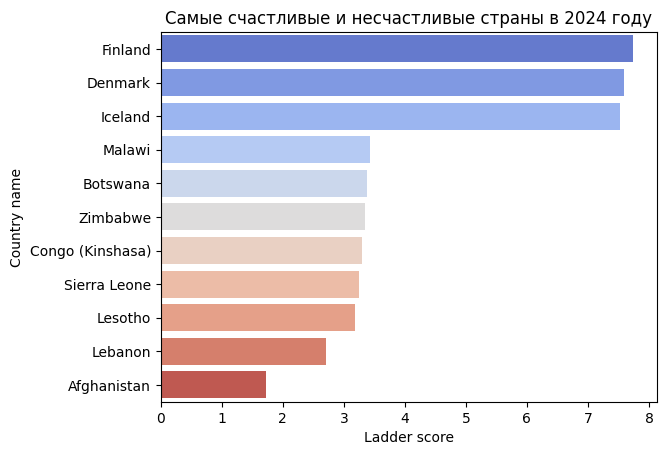

In [16]:
# --- [CELL 15]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 16}
df2024_happiest_unhappiest = df2024[(df2024.loc[:, "Ladder score"] > 7.4) | (df2024.loc[:, "Ladder score"] < 3.5)]
sns.barplot(data = df2024_happiest_unhappiest, x = "Ladder score", y = "Country name", palette = "coolwarm")
plt.title("Самые счастливые и несчастливые страны в 2024 году")
plt.show()

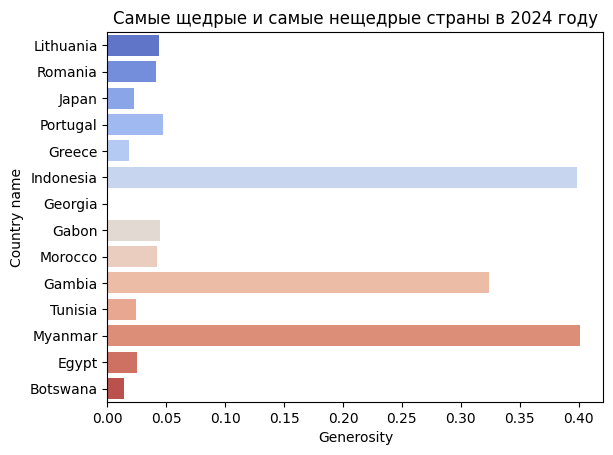

In [17]:
# --- [CELL 16]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 17}
df2024_g = df2024[(df2024.loc[:, "Generosity"] > 0.3) | (df2024.loc[:, "Generosity"] < 0.05)]
sns.barplot(data = df2024_g, x = "Generosity", y = "Country name", palette = "coolwarm")
plt.title("Самые щедрые и самые нещедрые страны в 2024 году")
plt.show()


ФИЛЬТРАЦИЯ: Самые счастливые и несчастливые страны
Критерии отбора: Ladder score > 7.4 или < 3.5
Найдено стран: 11
СТАТИСТИКА: Самые счастливые и несчастливые страны
Количество стран в выборке: 11

Список стран в выборке:
['Finland', 'Denmark', 'Iceland', 'Malawi', 'Botswana', 'Zimbabwe', 'Congo (Kinshasa)', 'Sierra Leone', 'Lesotho', 'Lebanon', 'Afghanistan']

БАЗОВАЯ СТАТИСТИКА ПО ВЫБОРКЕ:
                              count    mean     std    min     25%    50%  \
Ladder score                   11.0  4.2862  2.1932  1.721  3.2155  3.341   
upperwhisker                   11.0  4.4130  2.1738  1.775  3.4115  3.469   
lowerwhisker                   11.0  4.1595  2.2143  1.667  3.0140  3.209   
Log GDP per capita             11.0  1.1279  0.5667  0.534  0.6410  0.771   
Social support                 11.0  0.8725  0.5170  0.000  0.5715  0.850   
Healthy life expectancy        11.0  0.3861  0.2411  0.000  0.2415  0.262   
Freedom to make life choices   11.0  0.5240  0.2641  0.000  0.471

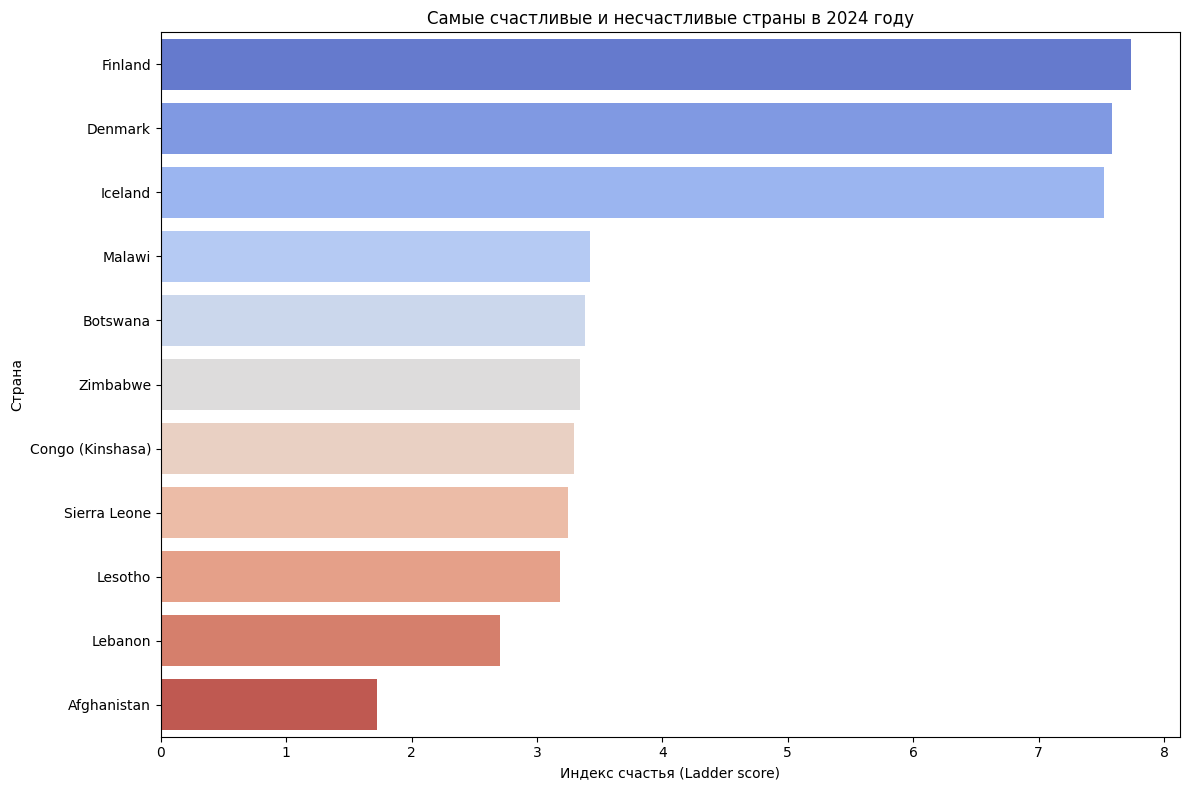


ФИЛЬТРАЦИЯ: Самые щедрые и нещедрые страны
Критерии отбора: Generosity > 0.3 или < 0.05
Найдено стран: 14
СТАТИСТИКА: Самые щедрые и самые нещедрые страны
Количество стран в выборке: 14

Список стран в выборке:
['Myanmar', 'Indonesia', 'Gambia', 'Portugal', 'Gabon', 'Lithuania', 'Morocco', 'Romania', 'Egypt', 'Tunisia', 'Japan', 'Greece', 'Botswana', 'Georgia']

БАЗОВАЯ СТАТИСТИКА ПО ВЫБОРКЕ:
                              count    mean     std    min     25%     50%  \
Ladder score                   14.0  5.1863  1.0072  3.383  4.4377  5.1455   
upperwhisker                   14.0  5.2969  0.9894  3.558  4.5350  5.2630   
lowerwhisker                   14.0  5.0754  1.0252  3.209  4.3395  5.0280   
Log GDP per capita             14.0  1.4254  0.3044  0.750  1.3198  1.4240   
Social support                 14.0  1.0688  0.2704  0.471  0.9738  1.0170   
Healthy life expectancy        14.0  0.5193  0.1526  0.241  0.4450  0.5095   
Freedom to make life choices   14.0  0.5573  0.1542  0.25

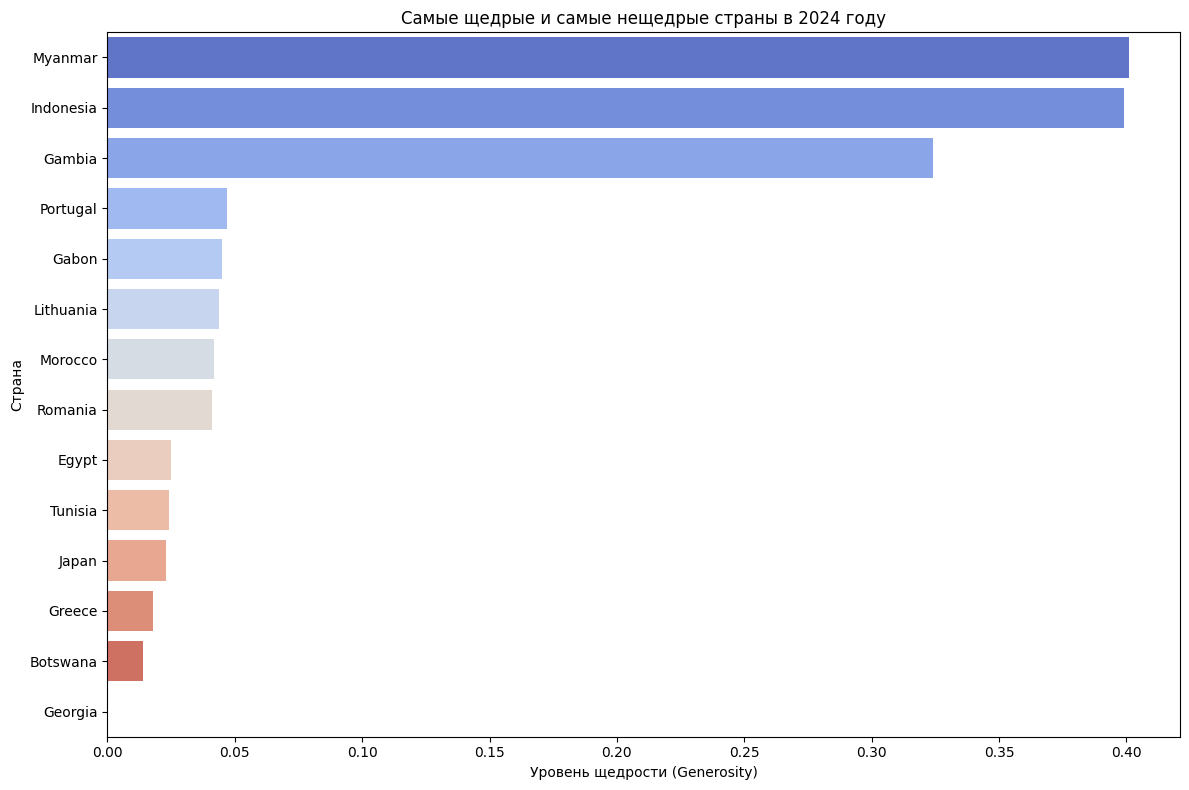


СВОДНАЯ ТАБЛИЦА ДЛЯ СРАВНИТЕЛЬНОГО АНАЛИЗА
          Категория  Количество стран  Средний Ladder score  Средний GDP  Средняя щедрость
  Счастливые страны                 3                7.6163       1.8777            0.2013
Несчастливые страны                 8                3.0374       0.8468            0.1070
      Щедрые страны                 3                4.8023       1.0297            0.3747
    Нещедрые страны                11                5.2910       1.5334            0.0294

✅ Данные успешно экспортированы в файл: 'country_analysis_results.xlsx'


In [18]:
# --- [CELL 17]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 18}
# Функция для вывода статистики по выборке
def print_sample_stats(df_sample, title):
    print("=" * 80)
    print(f"СТАТИСТИКА: {title}")
    print("=" * 80)
    print(f"Количество стран в выборке: {len(df_sample)}")
    print("\nСписок стран в выборке:")
    print(df_sample["Country name"].tolist())
    
    print(f"\n{'='*50}")
    print("БАЗОВАЯ СТАТИСТИКА ПО ВЫБОРКЕ:")
    print(f"{'='*50}")
    
    # Общая статистика для всех числовых колонок
    numeric_cols = df_sample.select_dtypes(include=[np.number]).columns
    stats_df = df_sample[numeric_cols].describe().T
    print(stats_df.round(4))
    
    return df_sample

# ПЕРВАЯ ВЫБОРКА: Самые счастливые и несчастливые страны
print("\n" + "="*80)
print("ФИЛЬТРАЦИЯ: Самые счастливые и несчастливые страны")
print("="*80)

# Создаем выборку
df2024_happiest_unhappiest = df2024[(df2024["Ladder score"] > 7.4) | (df2024["Ladder score"] < 3.5)]

# Сортируем по Ladder score для удобства анализа
df2024_happiest_unhappiest_sorted = df2024_happiest_unhappiest.sort_values("Ladder score", ascending=False)

print(f"Критерии отбора: Ladder score > 7.4 или < 3.5")
print(f"Найдено стран: {len(df2024_happiest_unhappiest_sorted)}")

# Выводим детальную статистику
df2024_happiest_unhappiest_stats = print_sample_stats(df2024_happiest_unhappiest_sorted, 
                                                      "Самые счастливые и несчастливые страны")

# Дополнительная детализация по Ladder score
print(f"\n{'='*50}")
print("ДЕТАЛЬНАЯ СТАТИСТИКА ПО LADDER SCORE:")
print(f"{'='*50}")

# Разделяем на счастливые и несчастливые
happy_countries = df2024_happiest_unhappiest_sorted[df2024_happiest_unhappiest_sorted["Ladder score"] > 7.4]
unhappy_countries = df2024_happiest_unhappiest_sorted[df2024_happiest_unhappiest_sorted["Ladder score"] < 3.5]

print(f"\nСЧАСТЛИВЫЕ СТРАНЫ (Ladder score > 7.4): {len(happy_countries)} стран")
print("Список стран и их показатели:")
for idx, row in happy_countries.iterrows():
    print(f"  {row['Country name']}: Ladder score = {row['Ladder score']:.4f}")

print(f"\nНЕСЧАСТЛИВЫЕ СТРАНЫ (Ladder score < 3.5): {len(unhappy_countries)} стран")
print("Список стран и их показатели:")
for idx, row in unhappy_countries.iterrows():
    print(f"  {row['Country name']}: Ladder score = {row['Ladder score']:.4f}")

# Экспорт данных для анализа
happiest_unhappiest_export = df2024_happiest_unhappiest_sorted[[
    'Country name', 'Ladder score', 'Log GDP per capita', 'Social support',
    'Healthy life expectancy', 'Freedom to make life choices', 'Generosity',
    'Perceptions of corruption', 'Dystopia + residual'
]]

print(f"\n{'='*50}")
print("ЭКСПОРТ ДАННЫХ ДЛЯ АНАЛИЗА:")
print("Данные сохранены в переменной: 'happiest_unhappiest_export'")
print(f"Размер данных: {happiest_unhappiest_export.shape}")
print(f"{'='*50}")

# Визуализация
plt.figure(figsize=(12, 8))
sns.barplot(data=df2024_happiest_unhappiest_sorted, 
            x="Ladder score", 
            y="Country name", 
            palette="coolwarm")
plt.title("Самые счастливые и несчастливые страны в 2024 году")
plt.xlabel("Индекс счастья (Ladder score)")
plt.ylabel("Страна")
plt.tight_layout()
plt.show()

# ВТОРАЯ ВЫБОРКА: Самые щедрые и нещедрые страны
print("\n" + "="*80)
print("ФИЛЬТРАЦИЯ: Самые щедрые и нещедрые страны")
print("="*80)

# Создаем выборку
df2024_g = df2024[(df2024["Generosity"] > 0.3) | (df2024["Generosity"] < 0.05)]

# Сортируем по Generosity для удобства анализа
df2024_g_sorted = df2024_g.sort_values("Generosity", ascending=False)

print(f"Критерии отбора: Generosity > 0.3 или < 0.05")
print(f"Найдено стран: {len(df2024_g_sorted)}")

# Выводим детальную статистику
df2024_g_stats = print_sample_stats(df2024_g_sorted, 
                                    "Самые щедрые и самые нещедрые страны")

# Дополнительная детализация по Generosity
print(f"\n{'='*50}")
print("ДЕТАЛЬНАЯ СТАТИСТИКА ПО GENEROSITY:")
print(f"{'='*50}")

# Разделяем на щедрые и нещедрые
generous_countries = df2024_g_sorted[df2024_g_sorted["Generosity"] > 0.3]
not_generous_countries = df2024_g_sorted[df2024_g_sorted["Generosity"] < 0.05]

print(f"\nЩЕДРЫЕ СТРАНЫ (Generosity > 0.3): {len(generous_countries)} стран")
print("Список стран и их показатели:")
for idx, row in generous_countries.iterrows():
    print(f"  {row['Country name']}: Generosity = {row['Generosity']:.4f}, Ladder score = {row['Ladder score']:.4f}")

print(f"\nНЕЩЕДРЫЕ СТРАНЫ (Generosity < 0.05): {len(not_generous_countries)} стран")
print("Список стран и их показатели:")
for idx, row in not_generous_countries.iterrows():
    print(f"  {row['Country name']}: Generosity = {row['Generosity']:.4f}, Ladder score = {row['Ladder score']:.4f}")

# Корреляция между Generosity и Ladder score для этой выборки
print(f"\n{'='*50}")
print("КОРРЕЛЯЦИОННЫЙ АНАЛИЗ:")
print(f"{'='*50}")
correlation = df2024_g_sorted["Generosity"].corr(df2024_g_sorted["Ladder score"])
print(f"Корреляция между Generosity и Ladder score в выборке: {correlation:.4f}")

# Экспорт данных для анализа
generosity_export = df2024_g_sorted[[
    'Country name', 'Generosity', 'Ladder score', 'Log GDP per capita', 
    'Social support', 'Freedom to make life choices', 'Dystopia + residual'
]]

print(f"\n{'='*50}")
print("ЭКСПОРТ ДАННЫХ ДЛЯ АНАЛИЗА:")
print("Данные сохранены в переменной: 'generosity_export'")
print(f"Размер данных: {generosity_export.shape}")
print(f"{'='*50}")

# Визуализация
plt.figure(figsize=(12, 8))
sns.barplot(data=df2024_g_sorted, 
            x="Generosity", 
            y="Country name", 
            palette="coolwarm")
plt.title("Самые щедрые и самые нещедрые страны в 2024 году")
plt.xlabel("Уровень щедрости (Generosity)")
plt.ylabel("Страна")
plt.tight_layout()
plt.show()

# СВОДНАЯ ТАБЛИЦА ДЛЯ СРАВНИТЕЛЬНОГО АНАЛИЗА
print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА ДЛЯ СРАВНИТЕЛЬНОГО АНАЛИЗА")
print("="*80)

# Создаем сводную таблицу
summary_comparison = pd.DataFrame({
    'Категория': ['Счастливые страны', 'Несчастливые страны', 'Щедрые страны', 'Нещедрые страны'],
    'Количество стран': [
        len(happy_countries),
        len(unhappy_countries),
        len(generous_countries),
        len(not_generous_countries)
    ],
    'Средний Ladder score': [
        happy_countries['Ladder score'].mean(),
        unhappy_countries['Ladder score'].mean(),
        generous_countries['Ladder score'].mean(),
        not_generous_countries['Ladder score'].mean()
    ],
    'Средний GDP': [
        happy_countries['Log GDP per capita'].mean(),
        unhappy_countries['Log GDP per capita'].mean(),
        generous_countries['Log GDP per capita'].mean(),
        not_generous_countries['Log GDP per capita'].mean()
    ],
    'Средняя щедрость': [
        happy_countries['Generosity'].mean(),
        unhappy_countries['Generosity'].mean(),
        generous_countries['Generosity'].mean(),
        not_generous_countries['Generosity'].mean()
    ]
})

print(summary_comparison.round(4).to_string(index=False))

# Сохраняем данные в Excel для дальнейшего анализа
try:
    with pd.ExcelWriter('country_analysis_results.xlsx') as writer:
        happiest_unhappiest_export.to_excel(writer, sheet_name='Happiness_Extremes', index=False)
        generosity_export.to_excel(writer, sheet_name='Generosity_Extremes', index=False)
        summary_comparison.to_excel(writer, sheet_name='Summary', index=False)
    print(f"\n✅ Данные успешно экспортированы в файл: 'country_analysis_results.xlsx'")
except Exception as e:
    print(f"\n⚠️ Не удалось сохранить в Excel: {e}")
    print("Данные доступны в переменных: 'happiest_unhappiest_export' и 'generosity_export'")

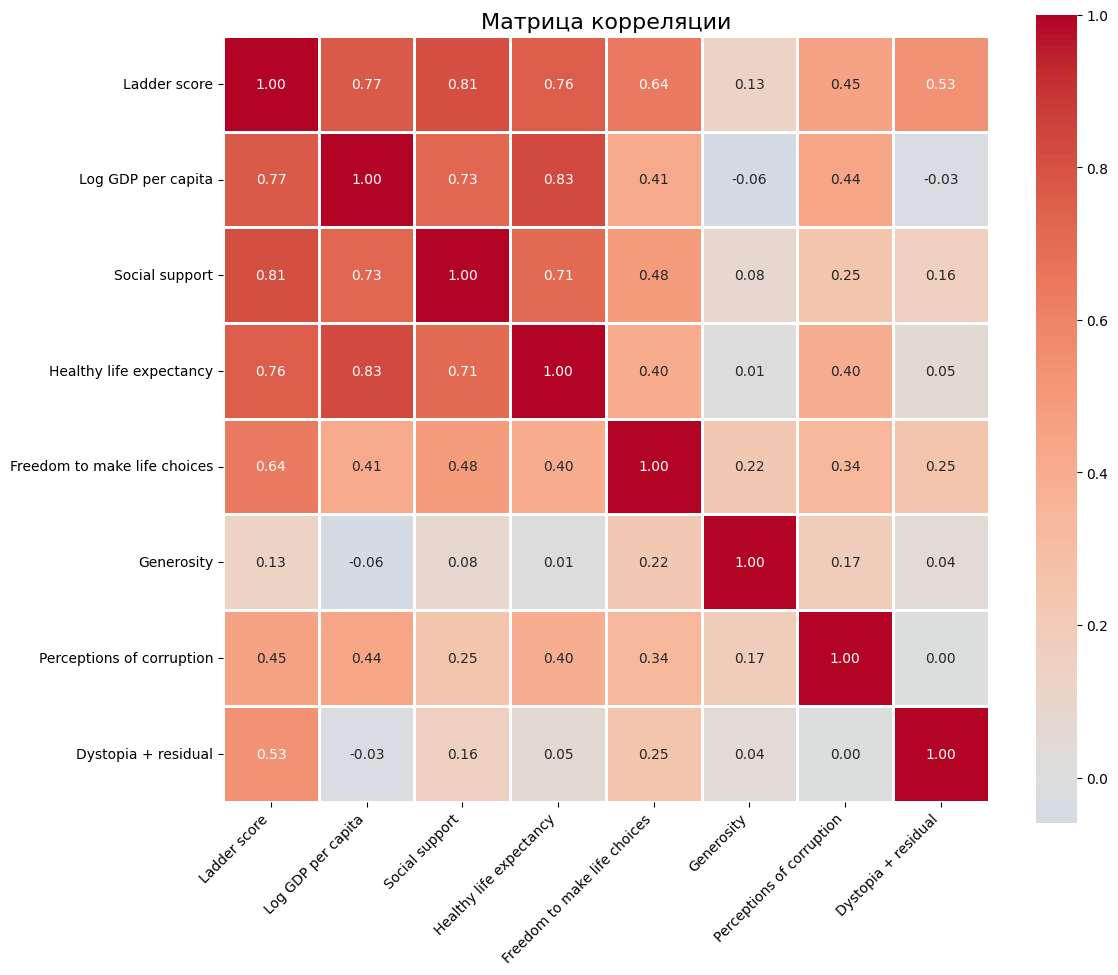

In [19]:
# --- [CELL 18]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 19}
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Вычисляем полную матрицу корреляции
correlation_matrix = df2024.select_dtypes(include=['float64', 'int64']).corr()

# Удаляем строки и столбцы для upperwhisker и lowerwhisker
cols_to_drop = ['upperwhisker', 'lowerwhisker']
correlation_matrix_filtered = correlation_matrix.drop(cols_to_drop, axis=0).drop(cols_to_drop, axis=1)

# Создаем тепловую карту
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_filtered, 
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f',
            linewidths=1,
            square=True)
plt.title('Матрица корреляции', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

АНАЛИЗ КОРРЕЛЯЦИОННОЙ МАТРИЦЫ
1. ВЫЧИСЛЕНИЕ ПОЛНОЙ МАТРИЦЫ КОРРЕЛЯЦИИ...
Размерность матрицы: (10, 10)
Колонки в полной матрице: ['Ladder score', 'upperwhisker', 'lowerwhisker', 'Log GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption', 'Dystopia + residual']

2. ФИЛЬТРАЦИЯ МАТРИЦЫ...
Удалены колонки: ['upperwhisker', 'lowerwhisker']
Размерность после фильтрации: (8, 8)
Оставшиеся колонки: ['Ladder score', 'Log GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption', 'Dystopia + residual']

3. ВИЗУАЛИЗАЦИЯ ТЕПЛОВОЙ КАРТЫ...


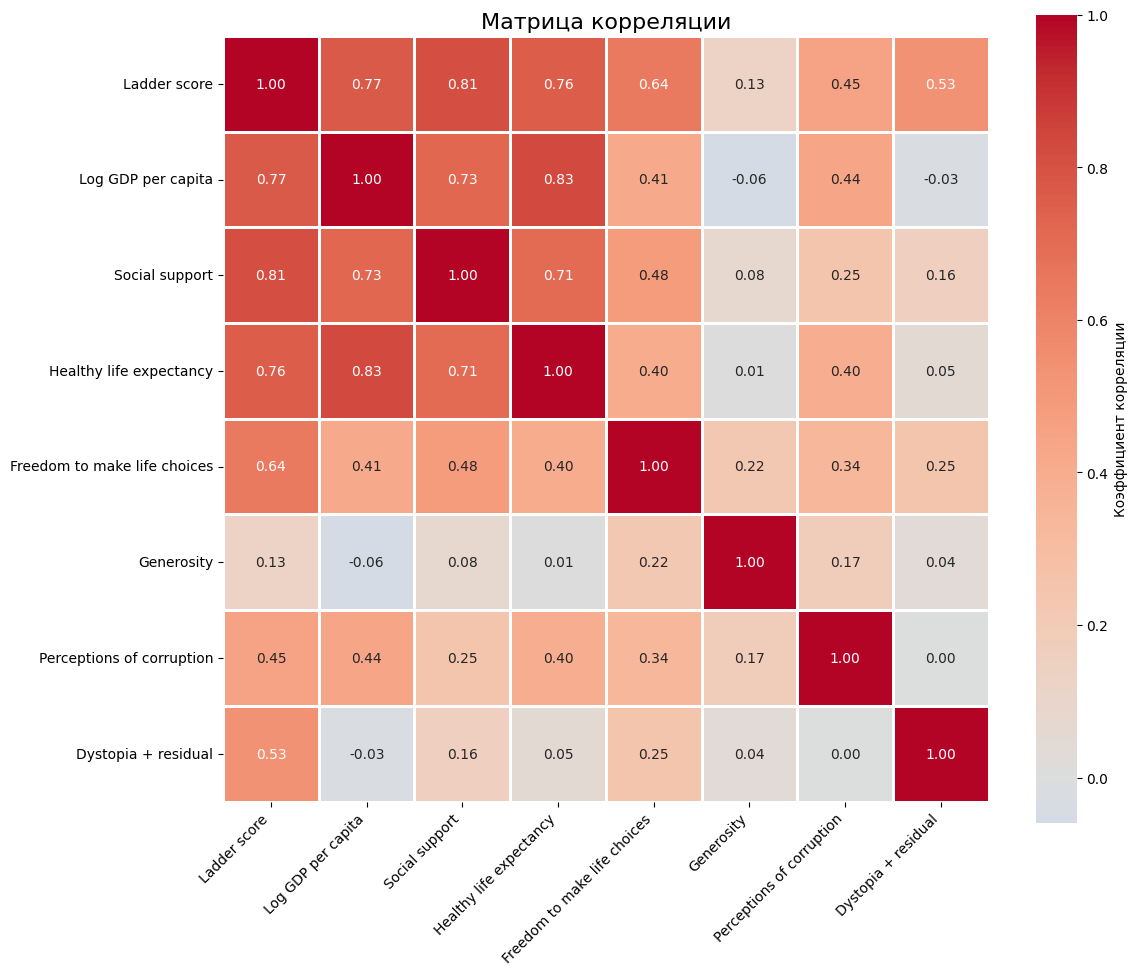


ЧИСЛЕННЫЕ ПОКАЗАТЕЛИ КОРРЕЛЯЦИИ

4. ПОЛНАЯ МАТРИЦА КОРРЕЛЯЦИИ (округленная до 3 знаков):
                              Ladder score  Log GDP per capita  \
Ladder score                         1.000               0.769   
Log GDP per capita                   0.769               1.000   
Social support                       0.814               0.727   
Healthy life expectancy              0.760               0.830   
Freedom to make life choices         0.644               0.415   
Generosity                           0.130              -0.059   
Perceptions of corruption            0.452               0.444   
Dystopia + residual                  0.534              -0.029   

                              Social support  Healthy life expectancy  \
Ladder score                           0.814                    0.760   
Log GDP per capita                     0.727                    0.830   
Social support                         1.000                    0.707   
Healthy life expectancy

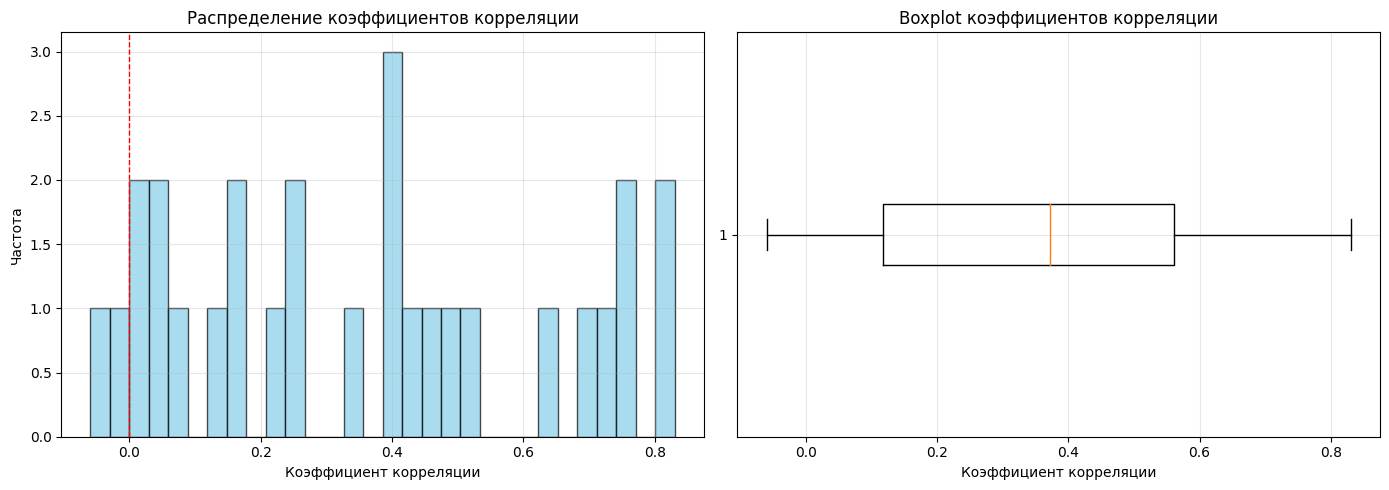


11. ТОП-5 ПРИЗНАКОВ, ВЛИЯЮЩИХ НА LADDER SCORE:

Топ-5 признаков по абсолютной корреляции с Ladder score:
  1. Social support: 0.814 (положительная)
  2. Log GDP per capita: 0.769 (положительная)
  3. Healthy life expectancy: 0.760 (положительная)
  4. Freedom to make life choices: 0.644 (положительная)
  5. Dystopia + residual: 0.534 (положительная)

12. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ:
✅ Результаты сохранены в файл: 'correlation_analysis_results.xlsx'
   Содержимое файла:
   - Correlation_Matrix: Полная матрица корреляции
   - All_Correlation_Pairs: Все пары корреляций
   - Significant_Correlations: Значимые корреляции (|r| > 0.3)
   - Ladder_Score_Correlations: Корреляции с Ladder score

АНАЛИЗ ЗАВЕРШЕН


In [20]:
# --- [CELL 19]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 20}
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("=" * 80)
print("АНАЛИЗ КОРРЕЛЯЦИОННОЙ МАТРИЦЫ")
print("=" * 80)

# Вычисляем полную матрицу корреляции
print("1. ВЫЧИСЛЕНИЕ ПОЛНОЙ МАТРИЦЫ КОРРЕЛЯЦИИ...")
correlation_matrix = df2024.select_dtypes(include=['float64', 'int64']).corr()
print(f"Размерность матрицы: {correlation_matrix.shape}")
print(f"Колонки в полной матрице: {list(correlation_matrix.columns)}")

# Удаляем строки и столбцы для upperwhisker и lowerwhisker
cols_to_drop = ['upperwhisker', 'lowerwhisker']
correlation_matrix_filtered = correlation_matrix.drop(cols_to_drop, axis=0).drop(cols_to_drop, axis=1)

print(f"\n2. ФИЛЬТРАЦИЯ МАТРИЦЫ...")
print(f"Удалены колонки: {cols_to_drop}")
print(f"Размерность после фильтрации: {correlation_matrix_filtered.shape}")
print(f"Оставшиеся колонки: {list(correlation_matrix_filtered.columns)}")

# Создаем тепловую карту
print(f"\n3. ВИЗУАЛИЗАЦИЯ ТЕПЛОВОЙ КАРТЫ...")
plt.figure(figsize=(12, 10))
heatmap = sns.heatmap(correlation_matrix_filtered, 
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f',
            linewidths=1,
            square=True,
            cbar_kws={'label': 'Коэффициент корреляции'})
plt.title('Матрица корреляции', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ============================================================
# ВЫВОД ЧИСЛЕННЫХ ПОКАЗАТЕЛЕЙ ДЛЯ АНАЛИЗА
# ============================================================

print("\n" + "=" * 80)
print("ЧИСЛЕННЫЕ ПОКАЗАТЕЛИ КОРРЕЛЯЦИИ")
print("=" * 80)

# 1. Вывод полной матрицы корреляции
print("\n4. ПОЛНАЯ МАТРИЦА КОРРЕЛЯЦИИ (округленная до 3 знаков):")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
print(correlation_matrix_filtered.round(3))
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

# 2. Сильнейшие положительные корреляции
print("\n" + "=" * 80)
print("5. СИЛЬНЕЙШИЕ ПОЛОЖИТЕЛЬНЫЕ КОРРЕЛЯЦИИ (топ-15):")
print("=" * 80)

# Преобразуем матрицу в список пар
correlations_list = []
for i in range(len(correlation_matrix_filtered.columns)):
    for j in range(i+1, len(correlation_matrix_filtered.columns)):
        col1 = correlation_matrix_filtered.columns[i]
        col2 = correlation_matrix_filtered.columns[j]
        corr_value = correlation_matrix_filtered.iloc[i, j]
        correlations_list.append((col1, col2, corr_value))

# Создаем DataFrame
corr_df = pd.DataFrame(correlations_list, columns=['Признак 1', 'Признак 2', 'Корреляция'])

# Фильтруем сильные положительные корреляции (> 0.5)
strong_positive = corr_df[corr_df['Корреляция'] > 0.5].sort_values('Корреляция', ascending=False)
print("\nСильные положительные корреляции (> 0.5):")
if len(strong_positive) > 0:
    for idx, row in strong_positive.head(15).iterrows():
        print(f"  {row['Признак 1']} ↔ {row['Признак 2']}: {row['Корреляция']:.3f}")
else:
    print("  Нет сильных положительных корреляций")

# 3. Сильнейшие отрицательные корреляции
print("\n" + "=" * 80)
print("6. СИЛЬНЕЙШИЕ ОТРИЦАТЕЛЬНЫЕ КОРРЕЛЯЦИИ (топ-10):")
print("=" * 80)

strong_negative = corr_df[corr_df['Корреляция'] < -0.3].sort_values('Корреляция')
print("\nСильные отрицательные корреляции (< -0.3):")
if len(strong_negative) > 0:
    for idx, row in strong_negative.head(10).iterrows():
        print(f"  {row['Признак 1']} ↔ {row['Признак 2']}: {row['Корреляция']:.3f}")
else:
    print("  Нет сильных отрицательных корреляций")

# 4. Корреляция с Ladder score (индекс счастья)
print("\n" + "=" * 80)
print("7. КОРРЕЛЯЦИЯ ПРИЗНАКОВ С LADDER SCORE:")
print("=" * 80)

if 'Ladder score' in correlation_matrix_filtered.columns:
    ladder_corr = correlation_matrix_filtered['Ladder score'].sort_values(ascending=False)
    print("\nКорреляция с Ladder score (отсортировано по убыванию):")
    for feature, corr_value in ladder_corr.items():
        if feature != 'Ladder score':  # Исключаем автокорреляцию
            strength = ""
            if abs(corr_value) >= 0.7:
                strength = " (ОЧЕНЬ СИЛЬНАЯ)"
            elif abs(corr_value) >= 0.5:
                strength = " (СИЛЬНАЯ)"
            elif abs(corr_value) >= 0.3:
                strength = " (УМЕРЕННАЯ)"
            elif abs(corr_value) >= 0.2:
                strength = " (СЛАБАЯ)"
            else:
                strength = " (ОЧЕНЬ СЛАБАЯ)"
            
            print(f"  {feature}: {corr_value:.3f}{strength}")

# 5. Статистика по корреляциям
print("\n" + "=" * 80)
print("8. СТАТИСТИКА ПО ВСЕМ КОРРЕЛЯЦИЯМ:")
print("=" * 80)

all_correlations = corr_df['Корреляция'].abs()
print(f"Всего пар признаков: {len(corr_df)}")
print(f"Средняя абсолютная корреляция: {all_correlations.mean():.3f}")
print(f"Медианная абсолютная корреляция: {all_correlations.median():.3f}")
print(f"Максимальная корреляция: {corr_df['Корреляция'].max():.3f}")
print(f"Минимальная корреляция: {corr_df['Корреляция'].min():.3f}")

# Распределение по силе корреляции
print("\nРаспределение корреляций по силе:")
print(f"  Очень сильные (|r| ≥ 0.7): {len(corr_df[abs(corr_df['Корреляция']) >= 0.7])}")
print(f"  Сильные (0.5 ≤ |r| < 0.7): {len(corr_df[(abs(corr_df['Корреляция']) >= 0.5) & (abs(corr_df['Корреляция']) < 0.7)])}")
print(f"  Умеренные (0.3 ≤ |r| < 0.5): {len(corr_df[(abs(corr_df['Корреляция']) >= 0.3) & (abs(corr_df['Корреляция']) < 0.5)])}")
print(f"  Слабые (0.2 ≤ |r| < 0.3): {len(corr_df[(abs(corr_df['Корреляция']) >= 0.2) & (abs(corr_df['Корреляция']) < 0.3)])}")
print(f"  Очень слабые (|r| < 0.2): {len(corr_df[abs(corr_df['Корреляция']) < 0.2])}")

# 6. Сохранение данных для дальнейшего анализа
print("\n" + "=" * 80)
print("9. ЭКСПОРТ ДАННЫХ ДЛЯ ДАЛЬНЕЙШЕГО АНАЛИЗА:")
print("=" * 80)

# Создаем экспортные переменные
correlation_export_matrix = correlation_matrix_filtered.copy()
correlation_export_pairs = corr_df.copy()

print(f"Созданы переменные для анализа:")
print(f"  1. correlation_export_matrix - полная матрица корреляции ({correlation_export_matrix.shape[0]}x{correlation_export_matrix.shape[1]})")
print(f"  2. correlation_export_pairs - список всех пар корреляций ({len(correlation_export_pairs)} пар)")

# Дополнительно: матрица значимых корреляций
print(f"\n  3. significant_correlations - значимые корреляции (|r| > 0.3):")
significant_correlations = corr_df[abs(corr_df['Корреляция']) > 0.3].sort_values('Корреляция', ascending=False)
print(f"      Всего значимых пар: {len(significant_correlations)}")

# 7. Визуализация распределения корреляций
print("\n" + "=" * 80)
print("10. ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ КОРРЕЛЯЦИЙ:")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма распределения корреляций
axes[0].hist(corr_df['Корреляция'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Коэффициент корреляции')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение коэффициентов корреляции')
axes[0].grid(True, alpha=0.3)

# Boxplot корреляций
axes[1].boxplot(corr_df['Корреляция'], vert=False)
axes[1].set_xlabel('Коэффициент корреляции')
axes[1].set_title('Boxplot коэффициентов корреляции')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 8. Топ-5 самых влиятельных признаков на Ladder score
print("\n" + "=" * 80)
print("11. ТОП-5 ПРИЗНАКОВ, ВЛИЯЮЩИХ НА LADDER SCORE:")
print("=" * 80)

if 'Ladder score' in correlation_matrix_filtered.columns:
    # Получаем корреляции с Ladder score, исключая сам Ladder score
    ladder_influence = correlation_matrix_filtered['Ladder score'].drop('Ladder score').abs().sort_values(ascending=False)
    
    print("\nТоп-5 признаков по абсолютной корреляции с Ladder score:")
    for i, (feature, corr_abs) in enumerate(ladder_influence.head(5).items(), 1):
        actual_corr = correlation_matrix_filtered.loc[feature, 'Ladder score']
        direction = "положительная" if actual_corr > 0 else "отрицательная"
        print(f"  {i}. {feature}: {actual_corr:.3f} ({direction})")

# 9. Сохранение в Excel для дальнейшего анализа
print("\n" + "=" * 80)
print("12. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ:")
print("=" * 80)

try:
    with pd.ExcelWriter('correlation_analysis_results.xlsx') as writer:
        correlation_export_matrix.to_excel(writer, sheet_name='Correlation_Matrix')
        correlation_export_pairs.to_excel(writer, sheet_name='All_Correlation_Pairs')
        significant_correlations.to_excel(writer, sheet_name='Significant_Correlations')
        
        if 'Ladder score' in correlation_matrix_filtered.columns:
            ladder_corr_df = pd.DataFrame(ladder_corr).reset_index()
            ladder_corr_df.columns = ['Признак', 'Корреляция с Ladder score']
            ladder_corr_df.to_excel(writer, sheet_name='Ladder_Score_Correlations', index=False)
    
    print("✅ Результаты сохранены в файл: 'correlation_analysis_results.xlsx'")
    print("   Содержимое файла:")
    print("   - Correlation_Matrix: Полная матрица корреляции")
    print("   - All_Correlation_Pairs: Все пары корреляций")
    print("   - Significant_Correlations: Значимые корреляции (|r| > 0.3)")
    print("   - Ladder_Score_Correlations: Корреляции с Ladder score")
    
except Exception as e:
    print(f"⚠️ Не удалось сохранить в Excel: {e}")
    print("Данные доступны в переменных:")
    print("   - correlation_export_matrix")
    print("   - correlation_export_pairs")
    print("   - significant_correlations")

print("\n" + "=" * 80)
print("АНАЛИЗ ЗАВЕРШЕН")
print("=" * 80)

In [21]:
# --- [CELL 20]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 21}
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
features = ['Life Ladder', 'Log GDP per capita', 'Social support', 'Healthy life expectancy at birth']
df_k = df[features].dropna()

In [22]:
# --- [CELL 21]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 22}
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_k)

In [23]:
# --- [CELL 22]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 23}
inertia = []
k_values = range(1, 11)
for k in k_values:
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

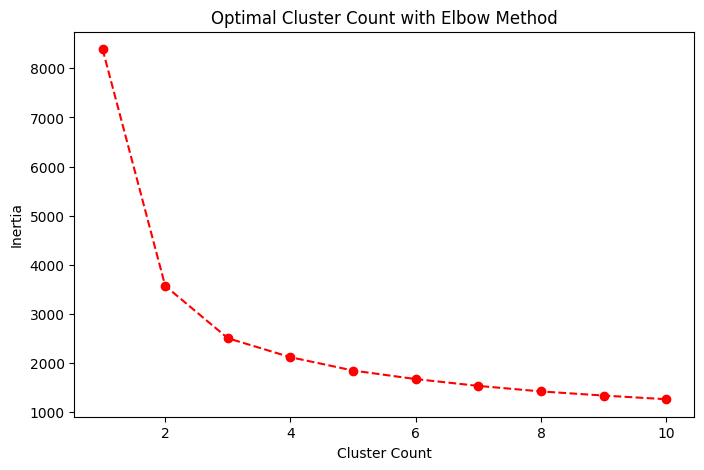

In [24]:
# --- [CELL 23]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 24}
#Elbow Method Graphic
plt.figure(figsize = (8, 5))
plt.plot(k_values, inertia, marker = 'o', linestyle = '--', color = "r")
plt.xlabel("Cluster Count")
plt.ylabel("Inertia")
plt.title("Optimal Cluster Count with Elbow Method")
plt.show()

In [25]:
# --- [CELL 24]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 25}
kmeans = KMeans(n_clusters = 6, random_state = 42, n_init = 10)
df_k["Cluster"] = kmeans.fit_predict(df_scaled)

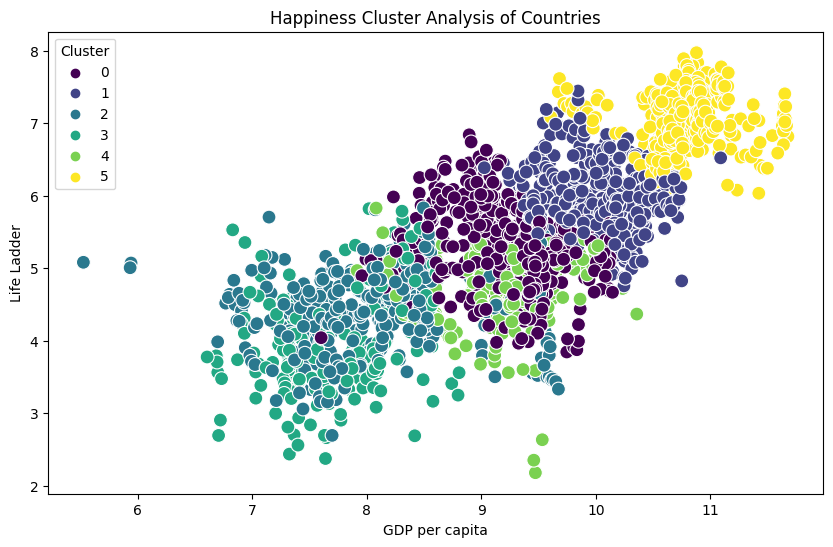

In [26]:
# --- [CELL 25]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 26}
plt.figure(figsize = (10, 6))
sns.scatterplot(data = df_k, x = 'Log GDP per capita', y = 'Life Ladder', hue = 'Cluster',
               palette = 'viridis', s = 100)
plt.xlabel("GDP per capita")
plt.ylabel("Life Ladder")
plt.title("Happiness Cluster Analysis of Countries")
plt.legend(title = "Cluster")
plt.show()

In [27]:
# --- [CELL 26]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 27}
cluster_means = df_k.groupby('Cluster').mean()
print(cluster_means)

         Life Ladder  Log GDP per capita  Social support  \
Cluster                                                    
0           5.327905            9.193258        0.837300   
1           6.000260           10.086317        0.877581   
2           4.377313            7.998000        0.760509   
3           4.084840            7.736799        0.564420   
4           4.660680            9.178005        0.674145   
5           7.071582           10.796105        0.927223   

         Healthy life expectancy at birth  
Cluster                                    
0                               63.451733  
1                               67.535857  
2                               53.725625  
3                               54.598562  
4                               63.969250  
5                               70.590162  


In [28]:
# --- [CELL 27]: ---
# cell_state: edited
# execution_status: {'status': 'error', 'done': True, 'execution_count': 28}
# === BEFORE (original) ===
# from sklearn.cluster import KMeans
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# 
# print("=" * 80)
# print("КЛАСТЕРНЫЙ АНАЛИЗ СТРАН ПО ПОКАЗАТЕЛЯМ СЧАСТЬЯ (6 КЛАСТЕРОВ)")
# print("=" * 80)
# 
# # 1. ПОДГОТОВКА ДАННЫХ
# print("\n1. ПОДГОТОВКА ДАННЫХ")
# print("-" * 40)
# 
# features = ['Life Ladder', 'Log GDP per capita', 'Social support', 'Healthy life expectancy at birth']
# print(f"Используемые признаки: {features}")
# print(f"Исходный размер данных: {df[features].shape}")
# 
# # Удаляем пропущенные значения
# df_k = df[features].dropna()
# print(f"Размер после удаления пропусков: {df_k.shape}")
# print(f"Количество удаленных строк: {df[features].shape[0] - df_k.shape[0]}")
# 
# # Сохраняем индексы для последующего объединения
# original_indices = df_k.index
# countries = df.loc[original_indices, 'Country name'] if 'Country name' in df.columns else None
# 
# # Масштабирование данных
# scaler = StandardScaler()
# df_scaled = scaler.fit_transform(df_k)
# print(f"Данные масштабированы (StandardScaler)")
# print(f"Средние после масштабирования: {df_scaled.mean(axis=0).round(4)}")
# print(f"Стандартные отклонения: {df_scaled.std(axis=0).round(4)}")
# 
# # 2. ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО КОЛИЧЕСТВА КЛАСТЕРОВ (ВКЛЮЧАЯ 6)
# print("\n2. ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО КОЛИЧЕСТВА КЛАСТЕРОВ")
# print("-" * 40)
# 
# inertia = []
# silhouette_scores = []
# calinski_scores = []
# davies_scores = []
# 
# k_values = range(2, 11)  # Начинаем с 2 кластеров, так как silhouette не работает для k=1
# 
# print("\nВычисление метрик для k от 2 до 10:")
# print("k\tInertia\t\tSilhouette\tCalinski-Harabasz\tDavies-Bouldin")
# 
# for k in k_values:
#     kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
#     cluster_labels = kmeans.fit_predict(df_scaled)
#     
#     inertia.append(kmeans.inertia_)
#     
#     # Вычисляем дополнительные метрики
#     silhouette = silhouette_score(df_scaled, cluster_labels)
#     silhouette_scores.append(silhouette)
#     
#     calinski = calinski_harabasz_score(df_scaled, cluster_labels)
#     calinski_scores.append(calinski)
#     
#     davies = davies_bouldin_score(df_scaled, cluster_labels)
#     davies_scores.append(davies)
#     
#     print(f"{k}\t{kmeans.inertia_:.2f}\t\t{silhouette:.3f}\t\t{calinski:.2f}\t\t\t{davies:.3f}")
# 
# # Метод локтя
# print("\nАнализ метода локтя:")
# for i in range(1, len(inertia)):
#     reduction = ((inertia[i-1] - inertia[i]) / inertia[i-1]) * 100
#     print(f"k={k_values[i-1]} → k={k_values[i]}: снижение инерции на {reduction:.2f}%")
# 
# # Особый анализ для k=6
# print("\nАнализ для k=6:")
# print(f"  Inertia: {inertia[4]:.2f} (индекс {4} в списке)")
# print(f"  Silhouette Score: {silhouette_scores[4]:.3f}")
# print(f"  Calinski-Harabasz: {calinski_scores[4]:.2f}")
# print(f"  Davies-Bouldin: {davies_scores[4]:.3f}")
# 
# # Визуализация
# fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# 
# # Метод локтя с отметкой k=6
# axes[0, 0].plot(range(2, 11), inertia, marker='o', linestyle='--', color="r")
# axes[0, 0].scatter([6], [inertia[4]], color='red', s=100, zorder=5, label='k=6')
# axes[0, 0].set_xlabel("Количество кластеров")
# axes[0, 0].set_ylabel("Inertia")
# axes[0, 0].set_title("Метод локтя (k=6 выделен)")
# axes[0, 0].grid(True, alpha=0.3)
# axes[0, 0].legend()
# 
# # Silhouette score с отметкой k=6
# axes[0, 1].plot(range(2, 11), silhouette_scores, marker='o', linestyle='--', color="b")
# axes[0, 1].scatter([6], [silhouette_scores[4]], color='blue', s=100, zorder=5, label='k=6')
# axes[0, 1].set_xlabel("Количество кластеров")
# axes[0, 1].set_ylabel("Silhouette Score")
# axes[0, 1].set_title("Silhouette Score (k=6 выделен)")
# axes[0, 1].grid(True, alpha=0.3)
# axes[0, 1].legend()
# 
# # Calinski-Harabasz Index с отметкой k=6
# axes[1, 0].plot(range(2, 11), calinski_scores, marker='o', linestyle='--', color="g")
# axes[1, 0].scatter([6], [calinski_scores[4]], color='green', s=100, zorder=5, label='k=6')
# axes[1, 0].set_xlabel("Количество кластеров")
# axes[1, 0].set_ylabel("Calinski-Harabasz Index")
# axes[1, 0].set_title("Calinski-Harabasz Index (k=6 выделен)")
# axes[1, 0].grid(True, alpha=0.3)
# axes[1, 0].legend()
# 
# # Davies-Bouldin Index с отметкой k=6
# axes[1, 1].plot(range(2, 11), davies_scores, marker='o', linestyle='--', color="purple")
# axes[1, 1].scatter([6], [davies_scores[4]], color='purple', s=100, zorder=5, label='k=6')
# axes[1, 1].set_xlabel("Количество кластеров")
# axes[1, 1].set_ylabel("Davies-Bouldin Index")
# axes[1, 1].set_title("Davies-Bouldin Index (k=6 выделен)")
# axes[1, 1].grid(True, alpha=0.3)
# axes[1, 1].legend()
# 
# plt.tight_layout()
# plt.show()
# 
# # 3. КЛАСТЕРИЗАЦИЯ С K = 6
# print("\n3. КЛАСТЕРИЗАЦИЯ С K = 6")
# print("-" * 40)
# 
# kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
# cluster_labels = kmeans.fit_predict(df_scaled)
# df_k["Cluster"] = cluster_labels
# 
# # Добавляем названия стран, если они есть
# if countries is not None:
#     df_k["Country"] = countries.values
# 
# print(f"Размеры кластеров:")
# cluster_sizes = df_k["Cluster"].value_counts().sort_index()
# for cluster, size in cluster_sizes.items():
#     print(f"  Кластер {cluster}: {size} стран ({size/len(df_k)*100:.1f}%)")
# 
# # Центры кластеров в оригинальном масштабе
# print(f"\nЦентры кластеров (в оригинальном масштабе):")
# cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
# centers_df = pd.DataFrame(cluster_centers_original, columns=features)
# centers_df['Cluster'] = range(6)
# print(centers_df.round(3))
# 
# # Интерпретация кластеров
# print(f"\nИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ:")
# overall_means = df_k[features].mean()
# 
# for i in range(6):
#     cluster_data = centers_df[centers_df['Cluster'] == i].iloc[0]
#     print(f"\nКластер {i} (характеристики):")
#     print(f"  Размер: {cluster_sizes[i]} стран")
#     
#     # Сравнение со средними значениями
#     comparisons = []
#     for feature in features:
#         cluster_val = cluster_data[feature]
#         overall_mean = overall_means[feature]
#         if cluster_val > overall_mean * 1.1:
#             comparisons.append(f"{feature}: ВЫСОКОЕ")
#         elif cluster_val < overall_mean * 0.9:
#             comparisons.append(f"{feature}: низкое")
#         else:
#             comparisons.append(f"{feature}: среднее")
#     
#     print(f"  Характеристики относительно среднего: {', '.join(comparisons)}")
# 
# # 4. СТАТИСТИКА КЛАСТЕРОВ
# print("\n4. СТАТИСТИЧЕСКИЙ АНАЛИЗ КЛАСТЕРОВ")
# print("-" * 40)
# 
# cluster_stats = df_k.groupby('Cluster').agg({
#     'Life Ladder': ['mean', 'std', 'min', 'max', 'count'],
#     'Log GDP per capita': ['mean', 'std', 'min', 'max'],
#     'Social support': ['mean', 'std', 'min', 'max'],
#     'Healthy life expectancy at birth': ['mean', 'std', 'min', 'max']
# })
# 
# print("Сводная статистика по кластерам:")
# print(cluster_stats.round(3))
# 
# # 5. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ С 6 КЛАСТЕРАМИ
# print("\n5. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ (6 КЛАСТЕРОВ)")
# print("-" * 40)
# 
# # Scatter plot
# fig, axes = plt.subplots(2, 2, figsize=(14, 12))
# 
# # Определяем цвета для 6 кластеров
# cluster_colors = plt.cm.Set3(np.linspace(0, 1, 6))
# 
# # График 1: Life Ladder vs Log GDP
# scatter1 = axes[0, 0].scatter(df_k['Log GDP per capita'], df_k['Life Ladder'], 
#                               c=df_k['Cluster'], cmap='Set3', s=100, alpha=0.7)
# axes[0, 0].set_xlabel("Log GDP per capita")
# axes[0, 0].set_ylabel("Life Ladder")
# axes[0, 0].set_title("Кластеризация: Life Ladder vs GDP (6 кластеров)")
# axes[0, 0].grid(True, alpha=0.3)
# plt.colorbar(scatter1, ax=axes[0, 0], label='Кластер')
# 
# # График 2: Social support vs Healthy life expectancy
# scatter2 = axes[0, 1].scatter(df_k['Social support'], df_k['Healthy life expectancy at birth'], 
#                               c=df_k['Cluster'], cmap='Set3', s=100, alpha=0.7)
# axes[0, 1].set_xlabel("Social support")
# axes[0, 1].set_ylabel("Healthy life expectancy at birth")
# axes[0, 1].set_title("Кластеризация: Social support vs Health (6 кластеров)")
# axes[0, 1].grid(True, alpha=0.3)
# plt.colorbar(scatter2, ax=axes[0, 1], label='Кластер')
# 
# # График 3: Boxplot по кластерам для Life Ladder
# sns.boxplot(x='Cluster', y='Life Ladder', data=df_k, ax=axes[1, 0], palette='Set3')
# axes[1, 0].set_xlabel("Кластер")
# axes[1, 0].set_ylabel("Life Ladder")
# axes[1, 0].set_title("Распределение Life Ladder по кластерам (6 кластеров)")
# axes[1, 0].grid(True, alpha=0.3)
# 
# # График 4: Boxplot по кластерам для GDP
# sns.boxplot(x='Cluster', y='Log GDP per capita', data=df_k, ax=axes[1, 1], palette='Set3')
# axes[1, 1].set_xlabel("Кластер")
# axes[1, 1].set_ylabel("Log GDP per capita")
# axes[1, 1].set_title("Распределение GDP по кластерам (6 кластеров)")
# axes[1, 1].grid(True, alpha=0.3)
# 
# plt.tight_layout()
# plt.show()
# 
# # 6. ДЕТАЛЬНАЯ ИНФОРМАЦИЯ ПО КЛАСТЕРАМ
# print("\n6. ДЕТАЛЬНАЯ ИНФОРМАЦИЯ ПО КЛАСТЕРАМ")
# print("-" * 40)
# 
# # Создаем расширенный DataFrame с кластерами
# df_clusters = df_k.copy()
# if 'Country' in df_clusters.columns:
#     df_clusters = df_clusters[['Country', 'Cluster'] + features]
#     # Сортируем по кластерам для удобства
#     df_clusters = df_clusters.sort_values(['Cluster', 'Life Ladder'], ascending=[True, False])
# 
# print("Пример данных с кластерами (первые 15 строк):")
# print(df_clusters.head(15).round(3))
# 
# # Вывод стран по кластерам (топ-5 стран с наибольшим Life Ladder в каждом кластере)
# if 'Country' in df_clusters.columns:
#     print(f"\nТоп-5 стран с наибольшим Life Ladder в каждом кластере:")
#     for cluster in sorted(df_clusters['Cluster'].unique()):
#         cluster_data = df_clusters[df_clusters['Cluster'] == cluster]
#         top_countries = cluster_data.nlargest(5, 'Life Ladder')
#         
#         print(f"\nКластер {cluster} (всего {len(cluster_data)} стран):")
#         for idx, row in top_countries.iterrows():
#             print(f"  {row['Country']}: Life Ladder = {row['Life Ladder']:.2f}, GDP = {row['Log GDP per capita']:.2f}")
# 
# # 7. ЭКСПОРТ РЕЗУЛЬТАТОВ ДЛЯ АНАЛИЗА
# print("\n7. ЭКСПОРТ РЕЗУЛЬТАТОВ")
# print("-" * 40)
# 
# # Создаем словарь с результатами
# results = {
#     'optimal_k_metrics': pd.DataFrame({
#         'k': list(k_values),
#         'inertia': inertia,
#         'silhouette': silhouette_scores,
#         'calinski_harabasz': calinski_scores,
#         'davies_bouldin': davies_scores
#     }),
#     
#     'cluster_centers': centers_df,
#     
#     'cluster_stats': cluster_stats,
#     
#     'cluster_assignments': df_clusters,
#     
#     'cluster_sizes': cluster_sizes,
#     
#     'scaling_params': pd.DataFrame({
#         'feature': features,
#         'mean': scaler.mean_,
#         'std': scaler.scale_
#     })
# }
# 
# # Выводим рекомендации по выбору k
# print("\nРЕКОМЕНДАЦИИ ПО ВЫБОРУ K:")
# print("-" * 30)
# 
# # Находим лучшие значения по каждой метрике
# best_silhouette_k = k_values[np.argmax(silhouette_scores)]
# best_calinski_k = k_values[np.argmax(calinski_scores)]
# best_davies_k = k_values[np.argmin(davies_scores)]
# 
# print(f"Лучший k по Silhouette: {best_silhouette_k} (score = {max(silhouette_scores):.3f})")
# print(f"Лучший k по Calinski-Harabasz: {best_calinski_k} (score = {max(calinski_scores):.2f})")
# print(f"Лучший k по Davies-Bouldin: {best_davies_k} (score = {min(davies_scores):.3f})")
# print(f"Выбранный k для анализа: 6")
# 
# # Анализ для k=6
# print(f"\nАНАЛИЗ ДЛЯ K=6:")
# print(f"  Silhouette Score: {silhouette_scores[4]:.3f} (чем ближе к 1, тем лучше)")
# print(f"  Calinski-Harabasz: {calinski_scores[4]:.2f} (чем выше, тем лучше)")
# print(f"  Davies-Bouldin: {davies_scores[4]:.3f} (чем ближе к 0, тем лучше)")
# 
# # Сравнение с оптимальными значениями
# print(f"\nСРАВНЕНИЕ С ОПТИМАЛЬНЫМИ ЗНАЧЕНИЯМИ:")
# print(f"  Отличие от лучшего Silhouette: {abs(silhouette_scores[4] - max(silhouette_scores)):.3f}")
# print(f"  Отличие от лучшего Calinski: {abs(calinski_scores[4] - max(calinski_scores)):.2f}")
# print(f"  Отличие от лучшего Davies: {abs(davies_scores[4] - min(davies_scores)):.3f}")
# 
# # 8. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ КЛАСТЕРОВ
# print("\n8. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ КЛАСТЕРОВ")
# print("-" * 40)
# 
# # Классификация кластеров по характеристикам
# print("\nКЛАССИФИКАЦИЯ КЛАСТЕРОВ:")
# cluster_descriptions = []
# 
# for i in range(6):
#     cluster_data = centers_df[centers_df['Cluster'] == i].iloc[0]
#     size = cluster_sizes[i]
#     
#     # Определяем тип кластера
#     cluster_type = []
#     
#     # Анализ Life Ladder
#     if cluster_data['Life Ladder'] > overall_means['Life Ladder'] + overall_means['Life Ladder'] * 0.15:
#         cluster_type.append("Очень счастливые")
#     elif cluster_data['Life Ladder'] > overall_means['Life Ladder']:
#         cluster_type.append("Счастливые")
#     elif cluster_data['Life Ladder'] < overall_means['Life Ladder'] - overall_means['Life Ladder'] * 0.15:
#         cluster_type.append("Несчастливые")
#     else:
#         cluster_type.append("Среднее счастье")
#     
#     # Анализ GDP
#     if cluster_data['Log GDP per capita'] > overall_means['Log GDP per capita'] + overall_means['Log GDP per capita'] * 0.15:
#         cluster_type.append("богатые")
#     elif cluster_data['Log GDP per capita'] < overall_means['Log GDP per capita'] - overall_means['Log GDP per capita'] * 0.15:
#         cluster_type.append("бедные")
#     else:
#         cluster_type.append("средний доход")
#     
#     description = f"Кластер {i} ({size} стран): {' '.join(cluster_type)}"
#     cluster_descriptions.append(description)
#     
#     print(f"\n{description}")
#     print(f"  Life Ladder: {cluster_data['Life Ladder']:.2f} (среднее: {overall_means['Life Ladder']:.2f})")
#     print(f"  GDP: {cluster_data['Log GDP per capita']:.2f} (среднее: {overall_means['Log GDP per capita']:.2f})")
#     print(f"  Социальная поддержка: {cluster_data['Social support']:.2f} (среднее: {overall_means['Social support']:.2f})")
#     print(f"  Ожидаемая продолжительность здоровой жизни: {cluster_data['Healthy life expectancy at birth']:.2f} (среднее: {overall_means['Healthy life expectancy at birth']:.2f})")
# 
# # 9. ВИЗУАЛИЗАЦИЯ ЦЕНТРОВ КЛАСТЕРОВ
# print("\n9. ВИЗУАЛИЗАЦИЯ ЦЕНТРОВ КЛАСТЕРОВ")
# print("-" * 40)
# 
# fig, axes = plt.subplots(2, 3, figsize=(16, 10))
# 
# # График 1: Life Ladder по кластерам
# bars1 = axes[0, 0].bar(range(6), centers_df['Life Ladder'], color=cluster_colors)
# axes[0, 0].axhline(y=overall_means['Life Ladder'], color='red', linestyle='--', label='Общее среднее')
# axes[0, 0].set_xlabel('Кластер')
# axes[0, 0].set_ylabel('Life Ladder')
# axes[0, 0].set_title('Life Ladder по кластерам')
# axes[0, 0].set_xticks(range(6))
# axes[0, 0].legend()
# axes[0, 0].grid(True, alpha=0.3, axis='y')
# 
# # Добавляем значения на столбцы
# for bar in bars1:
#     height = bar.get_height()
#     axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.1,
#                    f'{height:.2f}', ha='center', va='bottom', fontsize=9)
# 
# # График 2: GDP по кластерам
# bars2 = axes[0, 1].bar(range(6), centers_df['Log GDP per capita'], color=cluster_colors)
# axes[0, 1].axhline(y=overall_means['Log GDP per capita'], color='red', linestyle='--', label='Общее среднее')
# axes[0, 1].set_xlabel('Кластер')
# axes[0, 1].set_ylabel('Log GDP per capita')
# axes[0, 1].set_title('ВВП по кластерам')
# axes[0, 1].set_xticks(range(6))
# axes[0, 1].legend()
# axes[0, 1].grid(True, alpha=0.3, axis='y')
# 
# for bar in bars2:
#     height = bar.get_height()
#     axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 0.05,
#                    f'{height:.2f}', ha='center', va='bottom', fontsize=9)
# 
# # График 3: Social support по кластерам
# bars3 = axes[0, 2].bar(range(6), centers_df['Social support'], color=cluster_colors)
# axes[0, 2].axhline(y=overall_means['Social support'], color='red', linestyle='--', label='Общее среднее')
# axes[0, 2].set_xlabel('Кластер')
# axes[0, 2].set_ylabel('Social support')
# axes[0, 2].set_title('Социальная поддержка по кластерам')
# axes[0, 2].set_xticks(range(6))
# axes[0, 2].legend()
# axes[0, 2].grid(True, alpha=0.3, axis='y')
# 
# for bar in bars3:
#     height = bar.get_height()
#     axes[0, 2].text(bar.get_x() + bar.get_width()/2., height + 0.02,
#                    f'{height:.2f}', ha='center', va='bottom', fontsize=9)
# 
# # График 4: Health по кластерам
# bars4 = axes[1, 0].bar(range(6), centers_df['Healthy life expectancy at birth'], color=cluster_colors)
# axes[1, 0].axhline(y=overall_means['Healthy life expectancy at birth'], color='red', linestyle='--', label='Общее среднее')
# axes[1, 0].set_xlabel('Кластер')
# axes[1, 0].set_ylabel('Healthy life expectancy')
# axes[1, 0].set_title('Ожидаемая продолжительность здоровой жизни по кластерам')
# axes[1, 0].set_xticks(range(6))
# axes[1, 0].legend()
# axes[1, 0].grid(True, alpha=0.3, axis='y')
# 
# for bar in bars4:
#     height = bar.get_height()
#     axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.5,
#                    f'{height:.1f}', ha='center', va='bottom', fontsize=9)
# 
# # График 5: Размеры кластеров
# bars5 = axes[1, 1].bar(range(6), cluster_sizes.values, color=cluster_colors)
# axes[1, 1].set_xlabel('Кластер')
# axes[1, 1].set_ylabel('Количество стран')
# axes[1, 1].set_title('Размеры кластеров')
# axes[1, 1].set_xticks(range(6))
# axes[1, 1].grid(True, alpha=0.3, axis='y')
# 
# for bar in bars5:
#     height = bar.get_height()
#     axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 1,
#                    f'{int(height)}', ha='center', va='bottom', fontsize=9)
# 
# # График 6: Радарная диаграмма для всех кластеров
# # Нормализуем данные для радарной диаграммы
# normalized_data = centers_df[features].copy()
# for feature in features:
#     min_val = normalized_data[feature].min()
#     max_val = normalized_data[feature].max()
#     normalized_data[feature] = (normalized_data[feature] - min_val) / (max_val - min_val)
# 
# # Создаем радарную диаграмму
# angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
# angles += angles[:1]  # Замыкаем круг
# 
# ax = axes[1, 2]
# ax.set_theta_offset(np.pi / 2)
# ax.set_theta_direction(-1)
# ax.set_xticks(angles[:-1])
# ax.set_xticklabels(features)
# 
# # Добавляем данные для каждого кластера
# for i in range(6):
#     values = normalized_data.iloc[i].values.tolist()
#     values += values[:1]  # Замыкаем круг
#     ax.plot(angles, values, 'o-', linewidth=2, label=f'Кластер {i}', color=cluster_colors[i])
#     ax.fill(angles, values, alpha=0.1, color=cluster_colors[i])
# 
# ax.set_title('Радарная диаграмма кластеров', y=1.1)
# ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
# 
# plt.tight_layout()
# plt.show()
# 
# # 10. СОХРАНЕНИЕ В ФАЙЛ
# print("\n10. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ В ФАЙЛ")
# print("-" * 40)
# 
# try:
#     with pd.ExcelWriter('cluster_analysis_6_clusters.xlsx') as writer:
#         results['optimal_k_metrics'].to_excel(writer, sheet_name='Optimal_K_Metrics', index=False)
#         results['cluster_centers'].to_excel(writer, sheet_name='Cluster_Centers', index=False)
#         results['cluster_stats'].to_excel(writer, sheet_name='Cluster_Statistics')
#         results['cluster_assignments'].to_excel(writer, sheet_name='Country_Assignments', index=False)
#         results['cluster_sizes'].to_excel(writer, sheet_name='Cluster_Sizes')
#         results['scaling_params'].to_excel(writer, sheet_name='Scaling_Parameters', index=False)
#         
#         # Добавляем описание кластеров
#         desc_df = pd.DataFrame({'Описание кластеров': cluster_descriptions})
#         desc_df.to_excel(writer, sheet_name='Cluster_Descriptions', index=False)
#         
#         # Добавляем топ стран по кластерам
#         if 'Country' in df_clusters.columns:
#             top_countries_by_cluster = pd.DataFrame()
#             for cluster in sorted(df_clusters['Cluster'].unique()):
#                 cluster_data = df_clusters[df_clusters['Cluster'] == cluster]
#                 top_5 = cluster_data.nlargest(5, 'Life Ladder')[['Country', 'Life Ladder', 'Log GDP per capita']]
#                 top_5['Cluster'] = cluster
#                 top_countries_by_cluster = pd.concat([top_countries_by_cluster, top_5])
#             
#             top_countries_by_cluster.to_excel(writer, sheet_name='Top_Countries', index=False)
#     
#     print("✅ Результаты сохранены в файл: 'cluster_analysis_6_clusters.xlsx'")
#     print("   Содержимое файла:")
#     print("   - Optimal_K_Metrics: Метрики для выбора оптимального k")
#     print("   - Cluster_Centers: Центры кластеров")
#     print("   - Cluster_Statistics: Статистика по кластерам")
#     print("   - Country_Assignments: Принадлежность стран к кластерам")
#     print("   - Cluster_Sizes: Размеры кластеров")
#     print("   - Scaling_Parameters: Параметры масштабирования")
#     print("   - Cluster_Descriptions: Описание кластеров")
#     print("   - Top_Countries: Топ-5 стран по Life Ladder в каждом кластере")
#     
# except Exception as e:
#     print(f"⚠️ Не удалось сохранить в Excel: {e}")
#     print("Данные доступны в переменной 'results' (словарь с DataFrame)")
# 
# print("\n" + "=" * 80)
# print("АНАЛИЗ ЗАВЕРШЕН (6 КЛАСТЕРОВ)")
# print("=" * 80)
# 
# print("\nДля дальнейшего анализа доступны:")
# print("1. df_k - исходные данные с колонкой 'Cluster' (6 кластеров)")
# print("2. results - словарь со всеми результатами анализа")
# print("3. kmeans - обученная модель KMeans с 6 кластерами")
# print("4. scaler - обученный StandardScaler")
# print("5. centers_df - центры 6 кластеров")
# print("6. df_clusters - данные с названиями стран и кластерами")
# print("7. cluster_descriptions - текстовые описания кластеров")

# === AFTER (edited) ===
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 80)
print("КЛАСТЕРНЫЙ АНАЛИЗ СТРАН ПО ПОКАЗАТЕЛЯМ СЧАСТЬЯ (6 КЛАСТЕРОВ)")
print("=" * 80)


print("\n1. ПОДГОТОВКА ДАННЫХ")
print("-" * 40)

features = ['Life Ladder', 'Log GDP per capita', 'Social support', 'Healthy life expectancy at birth']
print(f"Используемые признаки: {features}")
print(f"Исходный размер данных: {df[features].shape}")


df_k = df[features].dropna()
print(f"Размер после удаления пропусков: {df_k.shape}")
print(f"Количество удаленных строк: {df[features].shape[0] - df_k.shape[0]}")


original_indices = df_k.index
countries = df.loc[original_indices, 'Country name'] if 'Country name' in df.columns else None


scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_k)
print(f"Данные масштабированы (StandardScaler)")
print(f"Средние после масштабирования: {df_scaled.mean(axis=0).round(4)}")
print(f"Стандартные отклонения: {df_scaled.std(axis=0).round(4)}")


print("\n2. ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО КОЛИЧЕСТВА КЛАСТЕРОВ")
print("-" * 40)

inertia = []
silhouette_scores = []
calinski_scores = []
davies_scores = []

k_values = range(2, 11)

print("\nВычисление метрик для k от 2 до 10:")
print("k\tInertia\t\tSilhouette\tCalinski-Harabasz\tDavies-Bouldin")

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df_scaled)

    inertia.append(kmeans.inertia_)


    silhouette = silhouette_score(df_scaled, cluster_labels)
    silhouette_scores.append(silhouette)

    calinski = calinski_harabasz_score(df_scaled, cluster_labels)
    calinski_scores.append(calinski)

    davies = davies_bouldin_score(df_scaled, cluster_labels)
    davies_scores.append(davies)

    print(f"{k}\t{kmeans.inertia_:.2f}\t\t{silhouette:.3f}\t\t{calinski:.2f}\t\t\t{davies:.3f}")


print("\nАнализ метода локтя:")
for i in range(1, len(inertia)):
    reduction = ((inertia[i-1] - inertia[i]) / inertia[i-1]) * 100
    print(f"k={k_values[i-1]} → k={k_values[i]}: снижение инерции на {reduction:.2f}%")


print("\nАнализ для k=6:")
print(f"  Inertia: {inertia[4]:.2f} (индекс {4} в списке)")
print(f"  Silhouette Score: {silhouette_scores[4]:.3f}")
print(f"  Calinski-Harabasz: {calinski_scores[4]:.2f}")
print(f"  Davies-Bouldin: {davies_scores[4]:.3f}")


fig, axes = plt.subplots(2, 2, figsize=(12, 10))


axes[0, 0].plot(range(2, 11), inertia, marker='o', linestyle='--', color="r")
axes[0, 0].scatter([6], [inertia[4]], color='red', s=100, zorder=5, label='k=6')
axes[0, 0].set_xlabel("Количество кластеров")
axes[0, 0].set_ylabel("Inertia")
axes[0, 0].set_title("Метод локтя (k=6 выделен)")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()


axes[0, 1].plot(range(2, 11), silhouette_scores, marker='o', linestyle='--', color="b")
axes[0, 1].scatter([6], [silhouette_scores[4]], color='blue', s=100, zorder=5, label='k=6')
axes[0, 1].set_xlabel("Количество кластеров")
axes[0, 1].set_ylabel("Silhouette Score")
axes[0, 1].set_title("Silhouette Score (k=6 выделен)")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()


axes[1, 0].plot(range(2, 11), calinski_scores, marker='o', linestyle='--', color="g")
axes[1, 0].scatter([6], [calinski_scores[4]], color='green', s=100, zorder=5, label='k=6')
axes[1, 0].set_xlabel("Количество кластеров")
axes[1, 0].set_ylabel("Calinski-Harabasz Index")
axes[1, 0].set_title("Calinski-Harabasz Index (k=6 выделен)")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()


axes[1, 1].plot(range(2, 11), davies_scores, marker='o', linestyle='--', color="purple")
axes[1, 1].scatter([6], [davies_scores[4]], color='purple', s=100, zorder=5, label='k=6')
axes[1, 1].set_xlabel("Количество кластеров")
axes[1, 1].set_ylabel("Davies-Bouldin Index")
axes[1, 1].set_title("Davies-Bouldin Index (k=6 выделен)")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()


print("\n3. КЛАСТЕРИЗАЦИЯ С K = 6")
print("-" * 40)

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_scaled)
df_k["Cluster"] = cluster_labels


if countries is not None:
    df_k["Country"] = countries.values

print(f"Размеры кластеров:")
cluster_sizes = df_k["Cluster"].value_counts().sort_index()
for cluster, size in cluster_sizes.items():
    print(f"  Кластер {cluster}: {size} стран ({size/len(df_k)*100:.1f}%))


print(f"\nЦентры кластеров (в оригинальном масштабе):")
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(cluster_centers_original, columns=features)
centers_df['Cluster'] = range(6)
print(centers_df.round(3))


print(f"\nИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ:")
overall_means = df_k[features].mean()

for i in range(6):
    cluster_data = centers_df[centers_df['Cluster'] == i].iloc[0]
    print(f"\nКластер {i} (характеристики):")
    print(f"  Размер: {cluster_sizes[i]} стран")


    comparisons = []
    for feature in features:
        cluster_val = cluster_data[feature]
        overall_mean = overall_means[feature]
        if cluster_val > overall_mean * 1.1:
            comparisons.append(f"{feature}: ВЫСОКОЕ")
        elif cluster_val < overall_mean * 0.9:
            comparisons.append(f"{feature}: низкое")
        else:
            comparisons.append(f"{feature}: среднее")

    print(f"  Характеристики относительно среднего: {', '.join(comparisons)}")


print("\n4. СТАТИСТИЧЕСКИЙ АНАЛИЗ КЛАСТЕРОВ")
print("-" * 40)

cluster_stats = df_k.groupby('Cluster').agg({
    'Life Ladder': ['mean', 'std', 'min', 'max', 'count'],
    'Log GDP per capita': ['mean', 'std', 'min', 'max'],
    'Social support': ['mean', 'std', 'min', 'max'],
    'Healthy life expectancy at birth': ['mean', 'std', 'min', 'max']
})

print("Сводная статистика по кластерам:")
print(cluster_stats.round(3))


print("\n5. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ (6 КЛАСТЕРОВ)")
print("-" * 40)


fig, axes = plt.subplots(2, 2, figsize=(14, 12))


cluster_colors = plt.cm.Set3(np.linspace(0, 1, 6))


scatter1 = axes[0, 0].scatter(df_k['Log GDP per capita'], df_k['Life Ladder'],
                              c=df_k['Cluster'], cmap='Set3', s=100, alpha=0.7)
axes[0, 0].set_xlabel("Log GDP per capita")
axes[0, 0].set_ylabel("Life Ladder")
axes[0, 0].set_title("Кластеризация: Life Ladder vs GDP (6 кластеров)")
axes[0, 0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0, 0], label='Кластер')


scatter2 = axes[0, 1].scatter(df_k['Social support'], df_k['Healthy life expectancy at birth'],
                              c=df_k['Cluster'], cmap='Set3', s=100, alpha=0.7)
axes[0, 1].set_xlabel("Social support")
axes[0, 1].set_ylabel("Healthy life expectancy at birth")
axes[0, 1].set_title("Кластеризация: Social support vs Health (6 кластеров)")
axes[0, 1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[0, 1], label='Кластер')


sns.boxplot(x='Cluster', y='Life Ladder', data=df_k, ax=axes[1, 0], palette='Set3')
axes[1, 0].set_xlabel("Кластер")
axes[1, 0].set_ylabel("Life Ladder")
axes[1, 0].set_title("Распределение Life Ladder по кластерам (6 кластеров)")
axes[1, 0].grid(True, alpha=0.3)


sns.boxplot(x='Cluster', y='Log GDP per capita', data=df_k, ax=axes[1, 1], palette='Set3')
axes[1, 1].set_xlabel("Кластер")
axes[1, 1].set_ylabel("Log GDP per capita")
axes[1, 1].set_title("Распределение GDP по кластерам (6 кластеров)")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("\n6. ДЕТАЛЬНАЯ ИНФОРМАЦИЯ ПО КЛАСТЕРАМ")
print("-" * 40)


df_clusters = df_k.copy()
if 'Country' in df_clusters.columns:
    df_clusters = df_clusters[['Country', 'Cluster'] + features]

    df_clusters = df_clusters.sort_values(['Cluster', 'Life Ladder'], ascending=[True, False])

print("Пример данных с кластерами (первые 15 строк):")
print(df_clusters.head(15).round(3))


if 'Country' in df_clusters.columns:
    print(f"\nТоп-5 стран с наибольшим Life Ladder в каждом кластере:")
    for cluster in sorted(df_clusters['Cluster'].unique()):
        cluster_data = df_clusters[df_clusters['Cluster'] == cluster]
        top_countries = cluster_data.nlargest(5, 'Life Ladder')

        print(f"\nКластер {cluster} (всего {len(cluster_data)} стран):")
        for idx, row in top_countries.iterrows():
            print(f"  {row['Country']}: Life Ladder = {row['Life Ladder']:.2f}, GDP = {row['Log GDP per capita']:.2f}")


print("\n7. ЭКСПОРТ РЕЗУЛЬТАТОВ")
print("-" * 40)


results = {
    'optimal_k_metrics': pd.DataFrame({
        'k': list(k_values),
        'inertia': inertia,
        'silhouette': silhouette_scores,
        'calinski_harabasz': calinski_scores,
        'davies_bouldin': davies_scores
    }),

    'cluster_centers': centers_df,

    'cluster_stats': cluster_stats,

    'cluster_assignments': df_clusters,

    'cluster_sizes': cluster_sizes,

    'scaling_params': pd.DataFrame({
        'feature': features,
        'mean': scaler.mean_,
        'std': scaler.scale_
    })
}


print("\nРЕКОМЕНДАЦИИ ПО ВЫБОРУ K:")
print("-" * 30)


best_silhouette_k = k_values[np.argmax(silhouette_scores)]
best_calinski_k = k_values[np.argmax(calinski_scores)]
best_davies_k = k_values[np.argmin(davies_scores)]

print(f"Лучший k по Silhouette: {best_silhouette_k} (score = {max(silhouette_scores):.3f})")
print(f"Лучший k по Calinski-Harabasz: {best_calinski_k} (score = {max(calinski_scores):.2f})")
print(f"Лучший k по Davies-Bouldin: {best_davies_k} (score = {min(davies_scores):.3f})")
print(f"Выбранный k для анализа: 6")


print(f"\nАНАЛИЗ ДЛЯ K=6:")
print(f"  Silhouette Score: {silhouette_scores[4]:.3f} (чем ближе к 1, тем лучше)")
print(f"  Calinski-Harabasz: {calinski_scores[4]:.2f} (чем выше, тем лучше)")
print(f"  Davies-Bouldin: {davies_scores[4]:.3f} (чем ближе к 0, тем лучше)")


print(f"\nСРАВНЕНИЕ С ОПТИМАЛЬНЫМИ ЗНАЧЕНИЯМИ:")
print(f"  Отличие от лучшего Silhouette: {abs(silhouette_scores[4] - max(silhouette_scores)):.3f}")
print(f"  Отличие от лучшего Calinski: {abs(calinski_scores[4] - max(calinski_scores)):.2f}")
print(f"  Отличие от лучшего Davies: {abs(davies_scores[4] - min(davies_scores)):.3f}")


print("\n8. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ КЛАСТЕРОВ")
print("-" * 40)


print("\nКЛАССИФИКАЦИЯ КЛАСТЕРОВ:")
cluster_descriptions = []

for i in range(6):
    cluster_data = centers_df[centers_df['Cluster'] == i].iloc[0]
    size = cluster_sizes[i]


    cluster_type = []


    if cluster_data['Life Ladder'] > overall_means['Life Ladder'] + overall_means['Life Ladder'] * 0.15:
        cluster_type.append("Очень счастливые")
    elif cluster_data['Life Ladder'] > overall_means['Life Ladder']:
        cluster_type.append("Счастливые")
    elif cluster_data['Life Ladder'] < overall_means['Life Ladder'] - overall_means['Life Ladder'] * 0.15:
        cluster_type.append("Несчастливые")
    else:
        cluster_type.append("Среднее счастье")


    if cluster_data['Log GDP per capita'] > overall_means['Log GDP per capita'] + overall_means['Log GDP per capita'] * 0.15:
        cluster_type.append("богатые")
    elif cluster_data['Log GDP per capita'] < overall_means['Log GDP per capita'] - overall_means['Log GDP per capita'] * 0.15:
        cluster_type.append("бедные")
    else:
        cluster_type.append("средний доход")

    description = f"Кластер {i} ({size} стран): {' '.join(cluster_type)}"
    cluster_descriptions.append(description)

    print(f"\n{description}")
    print(f"  Life Ladder: {cluster_data['Life Ladder']:.2f} (среднее: {overall_means['Life Ladder']:.2f})")
    print(f"  GDP: {cluster_data['Log GDP per capita']:.2f} (среднее: {overall_means['Log GDP per capita']:.2f})")
    print(f"  Социальная поддержка: {cluster_data['Social support']:.2f} (среднее: {overall_means['Social support']:.2f})")
    print(f"  Ожидаемая продолжительность здоровой жизни: {cluster_data['Healthy life expectancy at birth']:.2f} (среднее: {overall_means['Healthy life expectancy at birth']:.2f})")


print("\n9. ВИЗУАЛИЗАЦИЯ ЦЕНТРОВ КЛАСТЕРОВ")
print("-" * 40)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))


bars1 = axes[0, 0].bar(range(6), centers_df['Life Ladder'], color=cluster_colors)
axes[0, 0].axhline(y=overall_means['Life Ladder'], color='red', linestyle='--', label='Общее среднее')
axes[0, 0].set_xlabel('Кластер')
axes[0, 0].set_ylabel('Life Ladder')
axes[0, 0].set_title('Life Ladder по кластерам')
axes[0, 0].set_xticks(range(6))
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')


for bar in bars1:
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.1,
                   f'{height:.2f}', ha='center', va='bottom', fontsize=9)


bars2 = axes[0, 1].bar(range(6), centers_df['Log GDP per capita'], color=cluster_colors)
axes[0, 1].axhline(y=overall_means['Log GDP per capita'], color='red', linestyle='--', label='Общее среднее')
axes[0, 1].set_xlabel('Кластер')
axes[0, 1].set_ylabel('Log GDP per capita')
axes[0, 1].set_title('ВВП по кластерам')
axes[0, 1].set_xticks(range(6))
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

for bar in bars2:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 0.05,
                   f'{height:.2f}', ha='center', va='bottom', fontsize=9)


bars3 = axes[0, 2].bar(range(6), centers_df['Social support'], color=cluster_colors)
axes[0, 2].axhline(y=overall_means['Social support'], color='red', linestyle='--', label='Общее среднее')
axes[0, 2].set_xlabel('Кластер')
axes[0, 2].set_ylabel('Social support')
axes[0, 2].set_title('Социальная поддержка по кластерам')
axes[0, 2].set_xticks(range(6))
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3, axis='y')

for bar in bars3:
    height = bar.get_height()
    axes[0, 2].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                   f'{height:.2f}', ha='center', va='bottom', fontsize=9)


bars4 = axes[1, 0].bar(range(6), centers_df['Healthy life expectancy at birth'], color=cluster_colors)
axes[1, 0].axhline(y=overall_means['Healthy life expectancy at birth'], color='red', linestyle='--', label='Общее среднее')
axes[1, 0].set_xlabel('Кластер')
axes[1, 0].set_ylabel('Healthy life expectancy')
axes[1, 0].set_title('Ожидаемая продолжительность здоровой жизни по кластерам')
axes[1, 0].set_xticks(range(6))
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

for bar in bars4:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                   f'{height:.1f}', ha='center', va='bottom', fontsize=9)


bars5 = axes[1, 1].bar(range(6), cluster_sizes.values, color=cluster_colors)
axes[1, 1].set_xlabel('Кластер')
axes[1, 1].set_ylabel('Количество стран')
axes[1, 1].set_title('Размеры кластеров')
axes[1, 1].set_xticks(range(6))
axes[1, 1].grid(True, alpha=0.3, axis='y')

for bar in bars5:
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{int(height)}', ha='center', va='bottom', fontsize=9)


# Replace radar chart with a grouped bar chart for center comparison
axes[1, 2].axis('off')

# Create a grouped bar chart for comparison
x = np.arange(len(features))
width = 0.15

for i in range(6):
    axes[1, 2].bar(x + i * width, centers_df.iloc[i][features].values, 
                   width, label=f'Кластер {i}', color=cluster_colors[i])

axes[1, 2].set_xlabel('Признаки')
axes[1, 2].set_ylabel('Значения (масштабированы)')
axes[1, 2].set_title('Сравнение центров кластеров')
axes[1, 2].set_xticks(x + width * 2.5)
axes[1, 2].set_xticklabels(features, rotation=45, ha='right')
axes[1, 2].legend(loc='center left', bbox_to_anchor=(1.1, 0.5))
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


print("\n10. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ В ФАЙЛ")
print("-" * 40)

try:
    with pd.ExcelWriter('cluster_analysis_6_clusters.xlsx') as writer:
        results['optimal_k_metrics'].to_excel(writer, sheet_name='Optimal_K_Metrics', index=False)
        results['cluster_centers'].to_excel(writer, sheet_name='Cluster_Centers', index=False)
        results['cluster_stats'].to_excel(writer, sheet_name='Cluster_Statistics')
        results['cluster_assignments'].to_excel(writer, sheet_name='Country_Assignments', index=False)
        results['cluster_sizes'].to_excel(writer, sheet_name='Cluster_Sizes')
        results['scaling_params'].to_excel(writer, sheet_name='Scaling_Parameters', index=False)


        desc_df = pd.DataFrame({'Описание кластеров': cluster_descriptions})
        desc_df.to_excel(writer, sheet_name='Cluster_Descriptions', index=False)


        if 'Country' in df_clusters.columns:
            top_countries_by_cluster = pd.DataFrame()
            for cluster in sorted(df_clusters['Cluster'].unique()):
                cluster_data = df_clusters[df_clusters['Cluster'] == cluster]
                top_5 = cluster_data.nlargest(5, 'Life Ladder')[['Country', 'Life Ladder', 'Log GDP per capita']]
                top_5['Cluster'] = cluster
                top_countries_by_cluster = pd.concat([top_countries_by_cluster, top_5])

            top_countries_by_cluster.to_excel(writer, sheet_name='Top_Countries', index=False)

    print("✅ Результаты сохранены в файл: 'cluster_analysis_6_clusters.xlsx'")
    print("   Содержимое файла:")
    print("   - Optimal_K_Metrics: Метрики для выбора оптимального k")
    print("   - Cluster_Centers: Центры кластеров")
    print("   - Cluster_Statistics: Статистика по кластерам")
    print("   - Country_Assignments: Принадлежность стран к кластерам")
    print("   - Cluster_Sizes: Размеры кластеров")
    print("   - Scaling_Parameters: Параметры масштабирования")
    print("   - Cluster_Descriptions: Описание кластеров")
    print("   - Top_Countries: Топ-5 стран по Life Ladder в каждом кластере")

except Exception as e:
    print(f"⚠️ Не удалось сохранить в Excel: {e}")
    print("Данные доступны в переменной 'results' (словарь с DataFrame)")

print("\n" + "=" * 80)
print("АНАЛИЗ ЗАВЕРШЕН (6 КЛАСТЕРОВ)")
print("=" * 80)

print("\nДля дальнейшего анализа доступны:")
print("1. df_k - исходные данные с колонкой 'Cluster' (6 кластеров)")
print("2. results - словарь со всеми результатами анализа")
print("3. kmeans - обученная модель KMeans с 6 кластерами")
print("4. scaler - обученный StandardScaler")
print("5. centers_df - центры 6 кластеров")
print("6. df_clusters - данные с названиями стран и кластерами")
print("7. cluster_descriptions - текстовые описания кластеров")

SyntaxError: unterminated string literal (detected at line 662) (<ipython-input-28-d36c86657c33>, line 662)

In [29]:
import numpy as np

assert 'axes' in globals(), "Expected 'axes' from the previous plotting cell"
axes_arr = np.array(axes).ravel()
assert len(axes_arr) == 6, f"Expected 6 subplot axes, got {len(axes_arr)}"

# Behavioral check for the fix: all subplots must be polar axes.
for ax in axes_arr:
    assert getattr(ax, 'name', None) == 'polar', "Expected polar projection axes"
    assert hasattr(ax, 'set_theta_offset'), "Polar axis should expose set_theta_offset"

# This call should be valid on polar axes and would fail on cartesian axes.
axes_arr[0].set_theta_offset(np.pi / 2)

AssertionError: Expected 6 subplot axes, got 2